# Glacier Melt Contribution to Streamflow — Regression & Lag Analysis
### `livneh_experiments.ipynb` | Millie Spencer | 2026

This notebook implements three analyses suggested by Ben to strengthen
the glacier-streamflow attribution:

1. **Multiple Linear Regression (MLR)** — quantify how much of monthly streamflow
   variance is explained by glacier runoff vs precipitation, temperature, and PET.
   Run in two flavours:
   - **Part A**: basin-average climate from CAMELS-CL (CR2MET only, highest spatial quality)
     with all three glacier runoff estimates (CR2MET / ERA5 / CRU) as sensitivity test
   - **Part B**: glacier-location climate from OGGM lista files — fully internally
     consistent (each dataset's own glacier runoff paired with its own climate variables)

2. **Lag cross-correlation analysis** — estimate the travel time between glacier
   melt occurring on the ice surface and that water appearing at the stream gauge.
   Tests lags of 0–6 months per basin.

3. **Noah's question** — which gauged basins have ≤100 km² of glacier area,
   and do they span a useful latitudinal range?

**Key assumption**: All analyses use monthly time steps (2000–2019) to match
OGGM's simulation resolution. Streamflow from CAMELS-CL `q_m3s_mon.csv`.


## 0. Imports and paths
All globals from the main OGGM notebook are assumed to be in memory (`RESULTS`, `GAUGE_INFO_FRAC`, `YEARS`, `DATASETS`, `DS_COLORS`, `OUT_DIR`, `CAMELS_FULL`, `OUTPUT_ROOT`, `CLUSTERS`).

In [1]:
# ── Cell 0: Imports, paths, and constants ─────────────────────────────────
#
# This notebook is designed to run standalone OR after the main
# all_chile_glacier_streamflow_v3.ipynb notebook.
#
# If running standalone, set RUN_STANDALONE = True and provide the path
# to the RESULTS.pkl file saved by the main notebook.
# If running after the main notebook, set RUN_STANDALONE = False and
# all variables will be inherited from memory.

import os, glob, pickle, json, calendar, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.colors import Normalize, to_hex
from matplotlib.cm import ScalarMappable
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore')

# ── Configuration ─────────────────────────────────────────────────────────
RUN_STANDALONE = True   # set False if running after main notebook

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUTPUT_ROOT  = f'{BASE_PATH}/Output'
CAMELS_FULL  = f'{BASE_PATH}/Full_CAMELS_all_basins/CAMELS_CL_v202201'
RGI_PATH     = f'{BASE_PATH}/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'
BOUNDS_PATH  = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'
OUT_DIR      = f'{OUTPUT_ROOT}/all_chile_results_v2'
LAG_DIR      = f'{OUT_DIR}/lag_analysis'
REG_DIR      = f'{OUT_DIR}/regression'
os.makedirs(LAG_DIR, exist_ok=True)
os.makedirs(REG_DIR, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
YEARS        = list(range(2000, 2020))
MONTHS       = list(range(1, 13))
YEAR_OFFSET  = 1
WATER_DENSITY = 1000
CLUSTERS     = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']
DATASETS     = {'CR2MET': 'TC', 'ERA5': 'ERA5', 'CRU': 'CRU'}
DS_COLORS    = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}
LAT_BOUNDARY         = -38.0
SUMMER_MONTHS        = [12, 1, 2, 3, 4]
WINTER_MONTHS        = [5, 6, 7, 8, 9, 10, 11]
SUMMER_THRESHOLD     = 0.70
WINTER_THRESHOLD     = 0.50
LISTA_START_YEAR     = 1960
LISTA_ROW_START      = (2000 - LISTA_START_YEAR) * 12
LISTA_ROW_END        = (2020 - LISTA_START_YEAR) * 12
MEGADROUGHT_YEARS    = list(range(2010, 2020))

def nc_path(dataset_name, cluster):
    tag = DATASETS[dataset_name]
    return (f'{OUTPUT_ROOT}/{dataset_name}/{cluster}/'
            f'run_output_2000_2019_hydro_{tag}_{cluster}.nc')

# ── Standalone mode: rebuild RESULTS, GAUGE_INFO_FRAC etc. from disk ──────
if RUN_STANDALONE:
    print('Running in STANDALONE mode — loading from disk...')

    # 1) Load RESULTS from pickle
    pkl_path = f'{OUT_DIR}/RESULTS.pkl'
    if not os.path.exists(pkl_path):
        raise FileNotFoundError(
            f'RESULTS.pkl not found at {pkl_path}.\n'
            'Run the main notebook first and make sure Cell 16 saved it.')
    with open(pkl_path, 'rb') as f:
        RESULTS = pickle.load(f)
    print(f'  RESULTS loaded: {sum(len(v) for v in RESULTS.values())} gauge-dataset pairs')

    # 2) Rebuild GAUGE_INFO_FRAC from spatial join CSVs + daily Q completeness
    #    (faster than re-running the full spatial join)
    nested_csv = f'{OUT_DIR}/spatial_join_nested.csv'
    if not os.path.exists(nested_csv):
        raise FileNotFoundError(
            f'spatial_join_nested.csv not found at {nested_csv}.\n'
            'Run Cell 7 of the main notebook first.')

    joined_valid = pd.read_csv(nested_csv, dtype={'gauge_id': str})
    q_wide = pd.read_csv(f'{CAMELS_FULL}/q_m3s_mon.csv', parse_dates=['date'])
    q_wide = q_wide[(q_wide['year'] >= 2000) &
                    (q_wide['year'] <= 2019)].reset_index(drop=True)

    # Rebuild GAUGE_INFO from nested CSV
    GAUGE_INFO = {}
    for gauge_id, grp in joined_valid.groupby('gauge_id'):
        GAUGE_INFO[gauge_id] = {
            'gauge_name':       grp['gauge_name'].iloc[0],
            'rgi_ids':          grp['RGIId'].tolist(),
            'n_glaciers':       len(grp),
            'glacier_area_km2': grp['Area'].sum(),
            'basin_area_km2':   grp['area_km2'].iloc[0],
            'clusters':         sorted(grp['Cluster'].unique().tolist()),
            'cen_lat':          grp['CenLat'].mean(),
            'cen_lon':          grp['CenLon'].mean(),
        }

    # Rebuild GAUGE_INFO_DEDUP from dedup CSV
    dedup_csv = f'{OUT_DIR}/spatial_join_dedup.csv'
    joined_dedup = pd.read_csv(dedup_csv, dtype={'gauge_id': str})
    GAUGE_INFO_DEDUP = {}
    for gauge_id, grp in joined_dedup.groupby('gauge_id'):
        GAUGE_INFO_DEDUP[gauge_id] = {
            'gauge_name':       grp['gauge_name'].iloc[0],
            'rgi_ids':          grp['RGIId'].tolist(),
            'n_glaciers':       len(grp),
            'glacier_area_km2': grp['Area'].sum(),
            'basin_area_km2':   grp['area_km2'].iloc[0],
            'clusters':         sorted(grp['Cluster'].unique().tolist()),
            'cen_lat':          grp['CenLat'].mean(),
            'primary_cluster':  grp['Cluster'].value_counts().index[0],
        }

    # Re-run Q completeness filter (fast — just daily CSV)
    print('  Running Q completeness filter...')
    q_day = pd.read_csv(f'{CAMELS_FULL}/q_m3s_day.csv', parse_dates=['date'])
    q_day = q_day[(q_day['year'] >= 1999) & (q_day['year'] <= 2019)].copy()

    def days_in_month(year, month):
        return calendar.monthrange(year, month)[1]

    def month_completeness(col, year, month):
        mask   = (q_day['year'] == year) & (q_day['month'] == month)
        vals   = col[mask]
        if len(vals) == 0:
            return 0.0
        n_valid = (vals.notna() & (vals >= 0)).sum()
        return n_valid / days_in_month(year, month)

    def assess_completeness(gauge_id, cen_lat):
        if gauge_id not in q_day.columns:
            return {'passes': False, 'complete_years': [],
                    'n_complete': 0, 'n_pre2010': 0, 'n_post2010': 0}
        col = q_day[gauge_id]
        complete_years = []
        for year in range(2000, 2020):
            summer_fracs = [
                month_completeness(col, year-1, 12),
                month_completeness(col, year, 1),
                month_completeness(col, year, 2),
                month_completeness(col, year, 3),
                month_completeness(col, year, 4),
            ]
            winter_fracs = [month_completeness(col, year, mo)
                            for mo in WINTER_MONTHS]
            if (all(f >= SUMMER_THRESHOLD for f in summer_fracs) and
                    sum(f >= WINTER_THRESHOLD for f in winter_fracs) >= 4):
                complete_years.append(year)
        n_pre  = sum(1 for y in complete_years if y <= 2009)
        n_post = sum(1 for y in complete_years if y >= 2010)
        n_tot  = len(complete_years)
        passes = ((n_pre >= 5 and n_post >= 5)
                  if cen_lat > LAT_BOUNDARY else n_tot >= 10)
        return {'passes': passes, 'complete_years': complete_years,
                'n_complete': n_tot, 'n_pre2010': n_pre, 'n_post2010': n_post}

    gauge_completeness = {}
    for gauge_id, info in GAUGE_INFO.items():
        gauge_completeness[gauge_id] = assess_completeness(
            gauge_id, info['cen_lat'])

    GAUGE_INFO_FRAC = {}
    GAUGE_INFO_MELT = {}
    for gauge_id, info in GAUGE_INFO.items():
        comp = gauge_completeness[gauge_id]
        if comp['passes']:
            i = dict(info)
            i.update({'n_complete_q_years': comp['n_complete'],
                      'n_pre2010':          comp['n_pre2010'],
                      'n_post2010':         comp['n_post2010'],
                      'complete_years':     comp['complete_years']})
            GAUGE_INFO_FRAC[gauge_id] = i
        else:
            GAUGE_INFO_MELT[gauge_id] = info

    # Sync GAUGE_INFO_FRAC with what's actually in RESULTS
    # (high-frac gauges were removed from RESULTS in Cell 17)
    gauges_in_results = set(RESULTS['CR2MET'].keys())
    GAUGE_INFO_FRAC   = {gid: info for gid, info in GAUGE_INFO_FRAC.items()
                         if gid in gauges_in_results}

    # Inject complete_years into RESULTS entries (needed downstream)
    for ds_name in RESULTS:
        for gauge_id, res in RESULTS[ds_name].items():
            if res is not None and 'complete_years' not in res:
                res['complete_years'] = gauge_completeness.get(
                    gauge_id, {}).get('complete_years', YEARS)

    print(f'  GAUGE_INFO_FRAC: {len(GAUGE_INFO_FRAC)} gauges')
    print(f'  GAUGE_INFO_DEDUP: {len(GAUGE_INFO_DEDUP)} gauges')

else:
    # Inheriting from main notebook — just confirm variables exist
    required = ['RESULTS', 'GAUGE_INFO_FRAC', 'GAUGE_INFO_DEDUP',
                'GAUGE_INFO', 'q_wide']
    missing  = [v for v in required if v not in dir()]
    if missing:
        raise NameError(
            f'Missing variables from main notebook: {missing}\n'
            'Either run the main notebook first or set RUN_STANDALONE = True.')
    print('Inheriting variables from main notebook ✓')

print('\nCell 0 complete.')
print(f'  RESULTS datasets:   {list(RESULTS.keys())}')
print(f'  Gauges for analysis: {len(GAUGE_INFO_FRAC)}')
print(f'  Output directory:   {OUT_DIR}')

Running in STANDALONE mode — loading from disk...
  RESULTS loaded: 429 gauge-dataset pairs
  Running Q completeness filter...
  GAUGE_INFO_FRAC: 143 gauges
  GAUGE_INFO_DEDUP: 157 gauges

Cell 0 complete.
  RESULTS datasets:   ['CR2MET', 'ERA5', 'CRU']
  Gauges for analysis: 143
  Output directory:   /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2


## 1. Load CAMELS-CL basin-average climate data

CAMELS-CL provides basin-averaged (area-weighted) monthly climate for all 516 gauges.
We load:
- `precip_cr2met_mm_mon.csv` — basin-average precipitation (mm/month, CR2MET)
- `tmean_cr2met_C_mon.csv` — basin-average mean temperature (°C, CR2MET)
- `pet_hargreaves_mm_mon.csv` — potential evapotranspiration (mm/month, Hargreaves)

These are the highest-quality basin-level climate variables available and will be
used as the climate predictors in Part A of the regression.


In [2]:
def load_camels_wide(fname, value_name):
    """Load a CAMELS-CL wide-format climate file, melt to long format."""
    df = pd.read_csv(f'{CAMELS_FULL}/{fname}')
    df = df[(df['year'] >= 2000) & (df['year'] <= 2019)].copy()
    id_cols = ['year', 'month']
    gauge_cols = [c for c in df.columns if c not in ['date','year','month','day']]
    df_long = df[id_cols + gauge_cols].melt(
        id_vars=id_cols, var_name='gauge_id', value_name=value_name)
    return df_long

print('Loading CAMELS-CL basin-average climate...')
precip_camels = load_camels_wide('precip_cr2met_mm_mon.csv', 'precip_mm')
tmean_camels  = load_camels_wide('tmean_cr2met_C_mon.csv',   'tmean_C')
pet_camels    = load_camels_wide('pet_hargreaves_mm_mon.csv', 'pet_mm')

# Merge all climate into one long DataFrame
camels_climate = precip_camels.merge(tmean_camels,  on=['year','month','gauge_id'])
camels_climate = camels_climate.merge(pet_camels,   on=['year','month','gauge_id'])
camels_climate['gauge_id'] = camels_climate['gauge_id'].astype(str)

print(f'CAMELS climate loaded: {len(camels_climate):,} rows')
print(f'Variables: {[c for c in camels_climate.columns if c not in ["year","month","gauge_id"]]}')
print(camels_climate.head(3))


Loading CAMELS-CL basin-average climate...
CAMELS climate loaded: 123,840 rows
Variables: ['precip_mm', 'tmean_C', 'pet_mm']
   year  month gauge_id   precip_mm   tmean_C  pet_mm
0  2000      1  1001001  193.042869 -2.974242  88.042
1  2000      2  1001001  142.846266 -2.910442  80.420
2  2000      3  1001001   84.655295  -4.28721  80.990


## 2. Load glacier-location climate from OGGM lista files (Part B)

For the internally-consistent regression (Part B), we need basin-level climate
from the same dataset that drove each OGGM simulation. The `lista_temp.csv` and
`lista_prec.csv` files in each cluster directory contain monthly temperature (°C)
and precipitation (mm/month) at each glacier's location.

**Caveat**: these are glacier-location averages, not full basin averages.
Glacier locations are typically higher-elevation and colder than the basin centroid.
This is a known limitation flagged in the methods.

We compute the mean across all glaciers in each gauge's catchment, weighted equally.


In [3]:
# ── Cell 2: Load glacier-location climate from OGGM lista files (Part B) ──
#
# For the internally consistent regression (Part B), we need basin-level
# climate from the same dataset that drove each OGGM simulation. The
# lista_temp.csv and lista_prec.csv files in each cluster directory contain
# monthly temperature (°C) and precipitation (mm/month) at each glacier's
# location.
#
# Caveat: glacier-location averages, not full basin averages. Glacier
# locations are typically higher-elevation and colder than the basin
# centroid. Flagged in methods.
#
# ERA5 lista files start in 1979 (not 1960 like CR2MET/CRU) because
# ERA5 reanalysis begins in 1979. Row offsets are computed per-dataset.

# Dataset-specific lista start years
LISTA_START_YEARS = {
    'CR2MET': 1960,   # 744 rows → 1960–2021
    'ERA5':   1979,   # 492 rows → 1979–2019
    'CRU':    1960,   # 744 rows → 1960–2021
}

def load_lista_for_gauge(gauge_id, ds_name, variable='temp'):
    """
    Load lista_temp or lista_prec for all glaciers in a gauge's catchment.
    Returns a DataFrame with columns: year, month, value (mean across glaciers).

    Note on lista_rgi.csv structure:
      - Row 0 is a spurious '0' header artifact — skip it
      - Rows 1..N are RGI IDs matching columns 0..N-1 of lista_temp/prec.csv
      - lista_temp.csv columns are named '0','0.1','0.2'...

    ERA5 lista files start in 1979 not 1960 — row offsets computed per dataset.
    """
    if gauge_id not in GAUGE_INFO_FRAC:
        return None
    info    = GAUGE_INFO_FRAC[gauge_id]
    rgi_ids = set(info['rgi_ids'])
    fname   = 'lista_temp.csv' if variable == 'temp' else 'lista_prec.csv'

    # Dataset-specific row offsets
    start_year = LISTA_START_YEARS.get(ds_name, 1960)
    row_start  = (2000 - start_year) * 12
    row_end    = (2020 - start_year) * 12

    rows_list = []
    for cl in info['clusters']:
        temp_path = f'{OUTPUT_ROOT}/{ds_name}/{cl}/{fname}'
        rgi_path  = f'{OUTPUT_ROOT}/{ds_name}/{cl}/lista_rgi.csv'

        if not os.path.exists(temp_path):
            continue

        df = pd.read_csv(temp_path, header=0)

        # Validate row range before slicing
        if row_start >= len(df) or row_end > len(df):
            print(f'  WARNING: {ds_name}/{cl}/{fname} has {len(df)} rows '
                  f'but need rows {row_start}:{row_end} — skipping')
            continue

        df = df.iloc[row_start:row_end]

        if os.path.exists(rgi_path):
            rgi_list = pd.read_csv(rgi_path, header=None)[0].tolist()
            rgi_list = [r for r in rgi_list if str(r).startswith('RGI')]

            if len(rgi_list) != df.shape[1]:
                # Mismatch — fall back to using all columns
                rows_list.append(df.values.mean(axis=1))
                continue

            mask = [i for i, r in enumerate(rgi_list) if r in rgi_ids]
            if mask:
                rows_list.append(df.iloc[:, mask].values.mean(axis=1))
        else:
            rows_list.append(df.values.mean(axis=1))

    if not rows_list:
        return None

    arr    = np.nanmean(np.array(rows_list), axis=0)
    n_mos  = len(arr)
    years  = np.repeat(range(2000, 2000 + n_mos // 12), 12)[:n_mos]
    months = (list(range(1, 13)) * (n_mos // 12))[:n_mos]
    return pd.DataFrame({'year': years, 'month': months, 'value': arr})

# ── Confirm row counts and start years per dataset ────────────────────────
print('Confirming lista file structure per dataset:')
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    test_path  = f'{OUTPUT_ROOT}/{ds_name}/WA1/lista_temp.csv'
    start_year = LISTA_START_YEARS[ds_name]
    row_start  = (2000 - start_year) * 12
    row_end    = (2020 - start_year) * 12
    if os.path.exists(test_path):
        n = len(pd.read_csv(test_path, header=0))
        status = '✓' if row_end <= n else '✗ OUT OF RANGE'
        print(f'  {ds_name}: {n} rows ({n//12} yrs from {start_year})  '
              f'using rows {row_start}:{row_end}  {status}')

# ── Test on Allipen for all three datasets ────────────────────────────────
print('\nTesting load_lista_for_gauge on Allipen (9402001):')
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    test = load_lista_for_gauge('9402001', ds_name, 'temp')
    if test is not None:
        print(f'  {ds_name}: {len(test)} rows  '
              f'sample Jan values: {test[test["month"]==1]["value"].values[:3].round(2)}')
    else:
        print(f'  {ds_name}: returned None — check paths')

# ── Build glacier-location climate cache ──────────────────────────────────
print('\nBuilding glacier-location climate cache...')
print('(~2-3 minutes for 137 gauges × 3 datasets)')

lista_climate = {}

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    n_ok = 0
    for gauge_id in GAUGE_INFO_FRAC:
        t_df = load_lista_for_gauge(gauge_id, ds_name, 'temp')
        p_df = load_lista_for_gauge(gauge_id, ds_name, 'prec')
        if t_df is not None and p_df is not None:
            merged = t_df.rename(columns={'value': 'glac_tmean_C'}).merge(
                p_df.rename(columns={'value': 'glac_prec_mm'}),
                on=['year', 'month'])
            lista_climate[(ds_name, gauge_id)] = merged
            n_ok += 1
    print(f'  {ds_name}: {n_ok} gauges loaded')

print('Done')

Confirming lista file structure per dataset:
  CR2MET: 744 rows (62 yrs from 1960)  using rows 480:720  ✓
  ERA5: 492 rows (41 yrs from 1979)  using rows 252:492  ✓
  CRU: 1428 rows (119 yrs from 1960)  using rows 480:720  ✓

Testing load_lista_for_gauge on Allipen (9402001):
  CR2MET: 240 rows  sample Jan values: [10.68 10.8  12.46]
  ERA5: 240 rows  sample Jan values: [11.81 11.37 13.26]
  CRU: 240 rows  sample Jan values: [15.08 14.98 15.24]

Building glacier-location climate cache...
(~2-3 minutes for 137 gauges × 3 datasets)
  CR2MET: 143 gauges loaded
  ERA5: 143 gauges loaded
  CRU: 143 gauges loaded
Done


## 3. Build the monthly regression dataset

For each gauge × month × dataset combination, we assemble:

| Column | Description |
|--------|-------------|
| `q_m3s` | Observed monthly streamflow (m³/s) |
| `glacier_runoff_m3` | OGGM-simulated glacier runoff (m³/month) |
| `glac_frac` | Glacier runoff as fraction of Q |
| `precip_mm` | Basin-average precipitation from CAMELS-CL (mm/month) |
| `tmean_C` | Basin-average temperature from CAMELS-CL (°C) |
| `pet_mm` | PET from Hargreaves (mm/month) |
| `glac_tmean_C` | Glacier-location temperature from OGGM lista files |
| `glac_prec_mm` | Glacier-location precipitation from OGGM lista files |
| `month` | Calendar month (1–12, used as seasonal predictor) |
| `glacier_area_km2` | Static glacier area of basin (km²) |
| `basin_area_km2` | Total basin area (km²) |
| `lat` | Basin centroid latitude |

Only rows with complete Q and glacier runoff are kept.
Only complete years (Alexis-validated) are included.


In [4]:
def build_regression_df(ds_name):
    """
    Build long-format monthly regression DataFrame for one climate dataset.
    Includes both CAMELS-CL basin-average climate and OGGM lista glacier-location climate.
    """
    rows = []
    for gauge_id in sorted(GAUGE_INFO_FRAC.keys()):
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        info         = GAUGE_INFO_FRAC[gauge_id]
        m            = res['monthly']
        complete_yrs = res['complete_years']

        # Filter to complete years only
        m = m[m['year'].isin(complete_yrs)].copy()

        # CAMELS-CL basin-average climate
        gc = camels_climate[camels_climate['gauge_id'] == gauge_id]

        # OGGM lista glacier-location climate
        lc = lista_climate.get((ds_name, gauge_id))

        for _, row in m.iterrows():
            yr, mo = int(row['year']), int(row['month'])

            # Q and glacier runoff
            q_val   = row.get('q_m3s', np.nan)
            glac_m3 = row['glacier_runoff_m3']
            q_mon   = row.get('q_m3_mon', np.nan)

            if pd.isna(q_val) or q_val <= 0:
                continue

            # CAMELS-CL climate for this gauge/month
            cc = gc[(gc['year'] == yr) & (gc['month'] == mo)]
            precip = cc['precip_mm'].values[0] if len(cc) else np.nan
            tmean  = cc['tmean_C'].values[0]   if len(cc) else np.nan
            pet    = cc['pet_mm'].values[0]     if len(cc) else np.nan

            # Glacier-location climate
            glac_t = np.nan
            glac_p = np.nan
            if lc is not None:
                lc_row = lc[(lc['year'] == yr) & (lc['month'] == mo)]
                if len(lc_row):
                    glac_t = lc_row['glac_tmean_C'].values[0]
                    glac_p = lc_row['glac_prec_mm'].values[0]

            rows.append({
                'gauge_id':          gauge_id,
                'gauge_name':        info['gauge_name'],
                'year':              yr,
                'month':             mo,
                'lat':               info['cen_lat'],
                'glacier_area_km2':  info['glacier_area_km2'],
                'basin_area_km2':    info['basin_area_km2'],
                'glac_pct_basin':    info['glacier_area_km2'] / info['basin_area_km2'] * 100,
                'cluster':           info['clusters'][0],
                'dataset':           ds_name,
                # Target
                'q_m3s':             q_val,
                'q_m3_mon':          q_mon,
                # Glacier predictor
                'glacier_runoff_m3': glac_m3,
                'glac_frac':         glac_m3 / q_mon if (not pd.isna(q_mon) and q_mon > 0) else np.nan,
                # CAMELS-CL basin-average climate
                'precip_mm':         precip,
                'tmean_C':           tmean,
                'pet_mm':            pet,
                # OGGM lista glacier-location climate
                'glac_tmean_C':      glac_t,
                'glac_prec_mm':      glac_p,
                # Seasonal
                'sin_month':         np.sin(2 * np.pi * mo / 12),
                'cos_month':         np.cos(2 * np.pi * mo / 12),
            })

    df = pd.DataFrame(rows)
    print(f'{ds_name}: {len(df):,} monthly observations, '
          f'{df["gauge_id"].nunique()} gauges')
    return df

print('Building regression datasets...')
REG_DATA = {}
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    REG_DATA[ds_name] = build_regression_df(ds_name)

print('\nDone. Sample (CR2MET):')
print(REG_DATA['CR2MET'][['gauge_id','year','month','q_m3s',
                           'glacier_runoff_m3','precip_mm',
                           'tmean_C','pet_mm']].head(5))


Building regression datasets...
CR2MET: 24,263 monthly observations, 143 gauges
ERA5: 24,263 monthly observations, 143 gauges
CRU: 24,263 monthly observations, 143 gauges

Done. Sample (CR2MET):
  gauge_id  year  month  q_m3s  glacier_runoff_m3   precip_mm   tmean_C  \
0  1001002  2002      1  1.182       68642.750500   63.772715 -4.058686   
1  1001002  2002      2  2.913      217029.508000  111.508738 -1.895736   
2  1001002  2002      3  3.548       81680.246000   90.722480 -2.425489   
3  1001002  2002      4  1.600           0.009104   34.822646 -3.875241   
4  1001002  2002      5  1.235           0.000000    9.064828 -5.358684   

    pet_mm  
0  104.916  
1   80.533  
2   82.999  
3   68.221  
4   56.732  


## 4. Part A — Panel regression using CAMELS-CL basin-average climate

**Motivation** (from collaborator discussion): A multiple linear regression lets us
quantify the *relative importance* of glacier melt vs precipitation vs temperature
in driving monthly streamflow. The coefficient on glacier runoff (β_glacier) tells
us how much Q increases per unit increase in glacier melt, holding all other
predictors constant. Comparing this coefficient across CR2MET / ERA5 / CRU tells
us how sensitive the result is to climate forcing choice.

**Part A setup:**
- Climate predictors: CAMELS-CL basin-average CR2MET precip, tmean, PET (same for all 3 regressions)
- Glacier predictor: changes across CR2MET / ERA5 / CRU
- Fixed effects: seasonal cycle encoded as sin/cos of month
- All predictors standardised (z-scored) so coefficients are comparable in magnitude
- Run as: (i) pooled panel across all 137 basins, (ii) per-basin separately

**Interpretation**: A larger standardised β_glacier = glacier melt is a stronger
independent driver of Q variation. R² tells you total variance explained.


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

PART_A_PREDICTORS = [
    'glacier_runoff_m3',   # key glacier predictor
    'precip_mm',           # CAMELS-CL basin precip (CR2MET)
    'tmean_C',             # CAMELS-CL basin temp (CR2MET)
    'pet_mm',              # PET Hargreaves
    'sin_month',           # seasonal cycle
    'cos_month',
]
PRED_LABELS = {
    'glacier_runoff_m3': 'Glacier runoff',
    'precip_mm':         'Precipitation',
    'tmean_C':           'Temperature',
    'pet_mm':            'PET',
    'sin_month':         'Season (sin)',
    'cos_month':         'Season (cos)',
}

def run_panel_regression(df, predictors, target='q_m3s', label=''):
    """
    Standardised OLS panel regression across all basins.
    Returns dict with coefficients, R2, and n.
    """
    sub = df[predictors + [target]].dropna()
    if len(sub) < 30:
        return None

    X = sub[predictors].values
    y = sub[target].values

    scaler = StandardScaler()
    X_std  = scaler.fit_transform(X)

    reg    = LinearRegression().fit(X_std, y)
    y_pred = reg.predict(X_std)
    r2     = r2_score(y, y_pred)

    # Bootstrap confidence intervals on coefficients (1000 samples)
    n_boot = 1000
    boot_coefs = np.zeros((n_boot, len(predictors)))
    rng = np.random.default_rng(42)
    for i in range(n_boot):
        idx = rng.integers(0, len(sub), len(sub))
        reg_b = LinearRegression().fit(X_std[idx], y[idx])
        boot_coefs[i] = reg_b.coef_

    ci_lo = np.percentile(boot_coefs, 2.5,  axis=0)
    ci_hi = np.percentile(boot_coefs, 97.5, axis=0)

    return {
        'label':      label,
        'n':          len(sub),
        'r2':         r2,
        'coef':       dict(zip(predictors, reg.coef_)),
        'ci_lo':      dict(zip(predictors, ci_lo)),
        'ci_hi':      dict(zip(predictors, ci_hi)),
        'intercept':  reg.intercept_,
        'scaler':     scaler,
    }

print('Running Part A panel regressions (CAMELS-CL climate)...')
PANEL_RESULTS_A = {}

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    result = run_panel_regression(
        REG_DATA[ds_name], PART_A_PREDICTORS,
        label=f'{ds_name} (panel, CAMELS-CL climate)')
    PANEL_RESULTS_A[ds_name] = result
    if result:
        print(f'\n{ds_name}:  R² = {result["r2"]:.3f}  n = {result["n"]:,}')
        for pred in PART_A_PREDICTORS:
            lo = result["ci_lo"][pred]
            hi = result["ci_hi"][pred]
            sig = '*' if (lo > 0 or hi < 0) else ''
            print(f'  {PRED_LABELS.get(pred, pred):20s}: '
                  f'{result["coef"][pred]:+.4f}  '
                  f'[{lo:+.4f}, {hi:+.4f}] {sig}')


Running Part A panel regressions (CAMELS-CL climate)...

CR2MET:  R² = 0.339  n = 24,263
  Glacier runoff      : +125.9468  [+120.9234, +131.4748] *
  Precipitation       : +60.9027  [+56.5174, +65.2475] *
  Temperature         : +28.7708  [+24.6020, +32.9177] *
  PET                 : +12.2090  [+8.7378, +15.9661] *
  Season (sin)        : -45.3931  [-49.3134, -41.7620] *
  Season (cos)        : -32.7658  [-36.9029, -28.7182] *

ERA5:  R² = 0.277  n = 24,263
  Glacier runoff      : +108.8966  [+100.9398, +118.8633] *
  Precipitation       : +63.5643  [+59.0795, +68.0425] *
  Temperature         : +23.8005  [+19.5594, +28.4197] *
  PET                 : +3.8937  [+0.0760, +8.0786] *
  Season (sin)        : -38.9856  [-43.3510, -35.0360] *
  Season (cos)        : -17.5948  [-22.3916, -13.0239] *

CRU:  R² = 0.325  n = 24,263
  Glacier runoff      : +122.7167  [+117.0034, +128.4765] *
  Precipitation       : +62.4869  [+58.0661, +66.9077] *
  Temperature         : +25.1781  [+20.9896, +2

### 4b. Per-basin regressions (Part A)

Running the regression separately for each basin reveals which basins show the
strongest glacier melt signal vs precipitation signal. Basins where β_glacier is
large and significant are the ones where glacier contributions are most detectable
in the streamflow record — regardless of their absolute glacier fraction.


In [6]:
# ── Cell 4b: Per-basin regressions (Part A) ───────────────────────────────
print('Running per-basin regressions (Part A)...')
PER_BASIN_A = {}

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    basin_results = []
    df = REG_DATA[ds_name]

    for gauge_id, grp in df.groupby('gauge_id'):
        result = run_panel_regression(
            grp, PART_A_PREDICTORS, label=gauge_id)
        if result is None:
            continue
        info = GAUGE_INFO_FRAC.get(gauge_id, {})
        basin_results.append({
            'gauge_id':         gauge_id,
            'gauge_name':       info.get('gauge_name', '')[:35],
            'lat':              info.get('cen_lat', np.nan),
            'cluster':          info.get('clusters', ['?'])[0],
            'glacier_area_km2': info.get('glacier_area_km2', np.nan),
            'n_obs':            result['n'],
            'r2':               result['r2'],
            **{f'coef_{p}': result['coef'][p] for p in PART_A_PREDICTORS},
            **{f'ci_lo_{p}': result['ci_lo'][p] for p in PART_A_PREDICTORS},
            **{f'ci_hi_{p}': result['ci_hi'][p] for p in PART_A_PREDICTORS},
        })

    if not basin_results:
        print(f'  {ds_name}: 0 basins fitted — check RESULTS and REG_DATA')
        PER_BASIN_A[ds_name] = pd.DataFrame()
        continue

    PER_BASIN_A[ds_name] = pd.DataFrame(basin_results).sort_values(
        'lat', ascending=False)
    print(f'  {ds_name}: {len(PER_BASIN_A[ds_name])} basins fitted')

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    if not PER_BASIN_A[ds_name].empty:
        PER_BASIN_A[ds_name].to_csv(
            f'{REG_DIR}/per_basin_regression_partA_{ds_name}.csv', index=False)
print('Per-basin results saved')

Running per-basin regressions (Part A)...
  CR2MET: 143 basins fitted
  ERA5: 143 basins fitted
  CRU: 143 basins fitted
Per-basin results saved


## 5. Part B — Internally consistent regression using glacier-location climate

In Part B, each dataset uses its own glacier runoff **and** its own temperature
and precipitation (from the OGGM `lista_temp.csv` / `lista_prec.csv` files).
This gives fully internally consistent regressions at the cost of glacier-location
rather than basin-average climate.

**Key difference from Part A**: precipitation and temperature now vary across
CR2MET / ERA5 / CRU, not just glacier runoff. This means any change in β_glacier
between datasets could reflect both the different glacier runoff estimates AND the
different climate context — so results should be compared with Part A to disentangle.


In [7]:
# ── Cell 5: Part B — Internally consistent regression using glacier-location climate ──
#
# Each dataset uses its own glacier runoff AND its own temperature and
# precipitation from the OGGM lista_temp/lista_prec files. This gives
# fully internally consistent regressions at the cost of glacier-location
# rather than basin-average climate.
#
# Key difference from Part A: precipitation and temperature now vary across
# CR2MET / ERA5 / CRU, not just glacier runoff. Any change in β_glacier
# between datasets could reflect both different glacier runoff estimates
# AND different climate context — compare with Part A to disentangle.

PART_B_PREDICTORS = [
    'glacier_runoff_m3',  # key glacier predictor
    'glac_prec_mm',       # glacier-location precip (dataset-specific)
    'glac_tmean_C',       # glacier-location temp (dataset-specific)
    'pet_mm',             # PET Hargreaves (same, from CAMELS-CL)
    'sin_month',
    'cos_month',
]
PRED_LABELS_B = {
    'glacier_runoff_m3': 'Glacier runoff',
    'glac_prec_mm':      'Precip (glac loc)',
    'glac_tmean_C':      'Temp (glac loc)',
    'pet_mm':            'PET',
    'sin_month':         'Season (sin)',
    'cos_month':         'Season (cos)',
}

# ── Panel regression Part B ───────────────────────────────────────────────
print('Running Part B panel regressions (glacier-location climate)...')
PANEL_RESULTS_B = {}

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    result = run_panel_regression(
        REG_DATA[ds_name], PART_B_PREDICTORS,
        label=f'{ds_name} (panel, glacier-location climate)')
    PANEL_RESULTS_B[ds_name] = result
    if result:
        print(f'\n{ds_name}:  R² = {result["r2"]:.3f}  n = {result["n"]:,}')
        for pred in PART_B_PREDICTORS:
            lo  = result['ci_lo'][pred]
            hi  = result['ci_hi'][pred]
            sig = '*' if (lo > 0 or hi < 0) else ''
            print(f'  {PRED_LABELS_B.get(pred, pred):22s}: '
                  f'{result["coef"][pred]:+.4f}  '
                  f'[{lo:+.4f}, {hi:+.4f}] {sig}')
    else:
        print(f'\n{ds_name}: regression returned None — '
              f'check lista_climate coverage for this dataset')

# ── Per-basin Part B ──────────────────────────────────────────────────────
print('\nRunning per-basin regressions (Part B)...')
PER_BASIN_B = {}

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    basin_results = []
    df = REG_DATA[ds_name]

    for gauge_id, grp in df.groupby('gauge_id'):
        result = run_panel_regression(grp, PART_B_PREDICTORS, label=gauge_id)
        if result is None:
            continue
        info = GAUGE_INFO_FRAC.get(gauge_id, {})
        basin_results.append({
            'gauge_id':         gauge_id,
            'gauge_name':       info.get('gauge_name', '')[:35],
            'lat':              info.get('cen_lat', np.nan),
            'cluster':          info.get('clusters', ['?'])[0],
            'glacier_area_km2': info.get('glacier_area_km2', np.nan),
            'n_obs':            result['n'],
            'r2':               result['r2'],
            **{f'coef_{p}': result['coef'][p] for p in PART_B_PREDICTORS},
            **{f'ci_lo_{p}': result['ci_lo'][p] for p in PART_B_PREDICTORS},
            **{f'ci_hi_{p}': result['ci_hi'][p] for p in PART_B_PREDICTORS},
        })

    if not basin_results:
        print(f'  {ds_name}: 0 basins fitted — lista_climate likely '
              f'incomplete for this dataset')
        PER_BASIN_B[ds_name] = pd.DataFrame()
        continue

    PER_BASIN_B[ds_name] = pd.DataFrame(basin_results).sort_values(
        'lat', ascending=False)
    PER_BASIN_B[ds_name].to_csv(
        f'{REG_DIR}/per_basin_regression_partB_{ds_name}.csv', index=False)
    print(f'  {ds_name}: {len(PER_BASIN_B[ds_name])} basins fitted')

# ── Diagnose lista_climate coverage ──────────────────────────────────────
print('\nDiagnosing lista_climate coverage:')
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    count = sum(1 for k in lista_climate if k[0] == ds_name)
    n_obs = len(REG_DATA[ds_name].dropna(subset=PART_B_PREDICTORS))
    print(f'  {ds_name}: {count} gauges in lista_climate  '
          f'| {n_obs:,} complete obs for Part B regression')

Running Part B panel regressions (glacier-location climate)...

CR2MET:  R² = 0.382  n = 24,263
  Glacier runoff        : +119.0330  [+114.2295, +124.4610] *
  Precip (glac loc)     : +79.4555  [+74.0798, +84.7571] *
  Temp (glac loc)       : +29.4446  [+25.6436, +33.2690] *
  PET                   : +11.8111  [+6.8698, +17.1821] *
  Season (sin)          : -41.4203  [-44.6512, -38.2753] *
  Season (cos)          : -22.9832  [-26.5349, -19.5196] *

ERA5:  R² = 0.345  n = 24,263
  Glacier runoff        : +96.8776  [+89.9945, +105.5292] *
  Precip (glac loc)     : +91.7326  [+86.5784, +96.8596] *
  Temp (glac loc)       : +26.4426  [+23.1007, +30.0143] *
  PET                   : +41.2892  [+36.1029, +47.3334] *
  Season (sin)          : -41.3816  [-44.8660, -38.0477] *
  Season (cos)          : -41.0711  [-45.8327, -36.8337] *

CRU:  R² = 0.306  n = 24,263
  Glacier runoff        : +119.0579  [+113.4217, +124.6191] *
  Precip (glac loc)     : +32.1990  [+28.4190, +35.8627] *
  Temp (gla

In [16]:
# ── Cell 5b: Exploring per-basin glacier coefficients (Part A) ────────────
#
# Answers four key questions about the per-basin regression results:
# 1. Which basins have the highest β_glacier?
# 2. Which basins show a statistically significant glacier signal?
# 3. Does β_glacier correlate with glacier area or fraction?
# 4. Do the three datasets agree on which basins are significant?

pred     = 'coef_glacier_runoff_m3'
lo_col   = 'ci_lo_glacier_runoff_m3'
hi_col   = 'ci_hi_glacier_runoff_m3'
DS_LIST  = ['CR2MET', 'ERA5', 'CRU']

# ── Question 1: Top 15 basins by β_glacier (CR2MET) ──────────────────────
print('=' * 65)
print('Q1: Top 15 basins by β_glacier (CR2MET, Part A)')
print('=' * 65)
df_cr2 = PER_BASIN_A['CR2MET'].copy()
df_cr2['sig'] = (df_cr2[lo_col] > 0) | (df_cr2[hi_col] < 0)
top15  = df_cr2.nlargest(15, pred)
print(f'{"gauge_id":10s} {"name":35s} {"lat":6s} {"β_glac":8s} '
      f'{"CI_lo":8s} {"CI_hi":8s} {"R²":6s} {"sig"}')
print('-' * 90)
for _, row in top15.iterrows():
    print(f'{row["gauge_id"]:10s} {row["gauge_name"]:35s} '
          f'{row["lat"]:6.2f} {row[pred]:8.2f} '
          f'{row[lo_col]:8.2f} {row[hi_col]:8.2f} '
          f'{row["r2"]:6.3f} {"*" if row["sig"] else ""}')

# ── Question 2: Significant vs non-significant basins ────────────────────
print('\n' + '=' * 65)
print('Q2: Significance summary across datasets')
print('=' * 65)
for ds_name in DS_LIST:
    df = PER_BASIN_A[ds_name].copy()
    df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
    n_sig   = df['sig'].sum()
    n_total = len(df)
    med_r2  = df['r2'].median()
    print(f'\n{ds_name}: {n_sig}/{n_total} basins significant '
          f'({n_sig/n_total*100:.0f}%)  |  median R² = {med_r2:.3f}')
    print(f'  Significant basins by cluster:')
    for cl, grp in df[df['sig']].groupby('cluster'):
        print(f'    {cl}: {len(grp)} basins')

# ── Question 3: β_glacier vs glacier area and fraction ───────────────────
print('\n' + '=' * 65)
print('Q3: Correlation of β_glacier with glacier characteristics')
print('=' * 65)

# Need mean_ann_frac from ANN_SUMMARIES if available
for ds_name in DS_LIST:
    df = PER_BASIN_A[ds_name].copy()
    df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)

    r_area, p_area = stats.pearsonr(
        np.log10(df['glacier_area_km2'].clip(lower=0.01)),
        df[pred])
    print(f'\n{ds_name}:')
    print(f'  β_glacier vs log10(glacier area):  r={r_area:.3f}  p={p_area:.3e}')

    # Among significant basins only
    sig = df[df['sig']]
    if len(sig) > 5:
        r_sig, p_sig = stats.pearsonr(
            np.log10(sig['glacier_area_km2'].clip(lower=0.01)),
            sig[pred])
        print(f'  (significant basins only, n={len(sig)}): '
              f'r={r_sig:.3f}  p={p_sig:.3e}')

# ── Question 4: Cross-dataset agreement on significance ───────────────────
print('\n' + '=' * 65)
print('Q4: Cross-dataset agreement on significant basins')
print('=' * 65)

sig_sets = {}
for ds_name in DS_LIST:
    df = PER_BASIN_A[ds_name].copy()
    df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
    sig_sets[ds_name] = set(df[df['sig']]['gauge_id'])

all_gauges   = set(PER_BASIN_A['CR2MET']['gauge_id'])
agree_all    = sig_sets['CR2MET'] & sig_sets['ERA5'] & sig_sets['CRU']
agree_none   = (all_gauges - sig_sets['CR2MET'] -
                sig_sets['ERA5'] - sig_sets['CRU'])
disagree     = all_gauges - agree_all - agree_none

print(f'  Significant in ALL 3 datasets:    {len(agree_all)} basins  '
      f'({len(agree_all)/len(all_gauges)*100:.0f}%) ← robust signal')
print(f'  Non-significant in ALL 3:         {len(agree_none)} basins  '
      f'({len(agree_none)/len(all_gauges)*100:.0f}%) ← no detectable signal')
print(f'  Disagree across datasets:         {len(disagree)} basins  '
      f'({len(disagree)/len(all_gauges)*100:.0f}%) ← dataset-sensitive')

print(f'\n  Basins significant in all 3 (robust glacier signal):')
df_robust = PER_BASIN_A['CR2MET'][
    PER_BASIN_A['CR2MET']['gauge_id'].isin(agree_all)
].sort_values('lat', ascending=False)
print(f'  {"gauge_id":10s} {"name":35s} {"lat":6s} {"cluster"}')
print('  ' + '-' * 65)
for _, row in df_robust.iterrows():
    print(f'  {row["gauge_id"]:10s} {row["gauge_name"]:35s} '
          f'{row["lat"]:6.2f} {row["cluster"]}')

Q1: Top 15 basins by β_glacier (CR2MET, Part A)
gauge_id   name                                lat    β_glac   CI_lo    CI_hi    R²     sig
------------------------------------------------------------------------------------------
12289001   Rio Serrano En Desembocadura        -51.04   314.59   213.70   402.72  0.776 *
11545000   Rio Baker Bajo ÑAdis                -46.77   170.48   -75.70   386.80  0.501 
11711000   Rio Pascua Ante Junta Rio Quetru    -48.44    97.47    16.96   186.26  0.887 *
11536004   Rio Baker En Angostura Chacabuco    -46.49    91.90    11.13   168.70  0.691 *
11542001   Rio Baker En Colonia                -46.69    88.55   -18.02   188.66  0.730 
12287001   Rio Grey Antes Junta Serrano        -50.95    83.43    54.58   110.22  0.881 *
11710000   Rio Pascua En Desague Lago O'Higgin -48.45    77.85    -0.15   164.45  0.879 
11530000   Rio Baker En Desague Lago Bertrand  -46.45    62.39     1.69   119.55  0.613 *
9140001    Rio Cautin En Almagro               -38.6

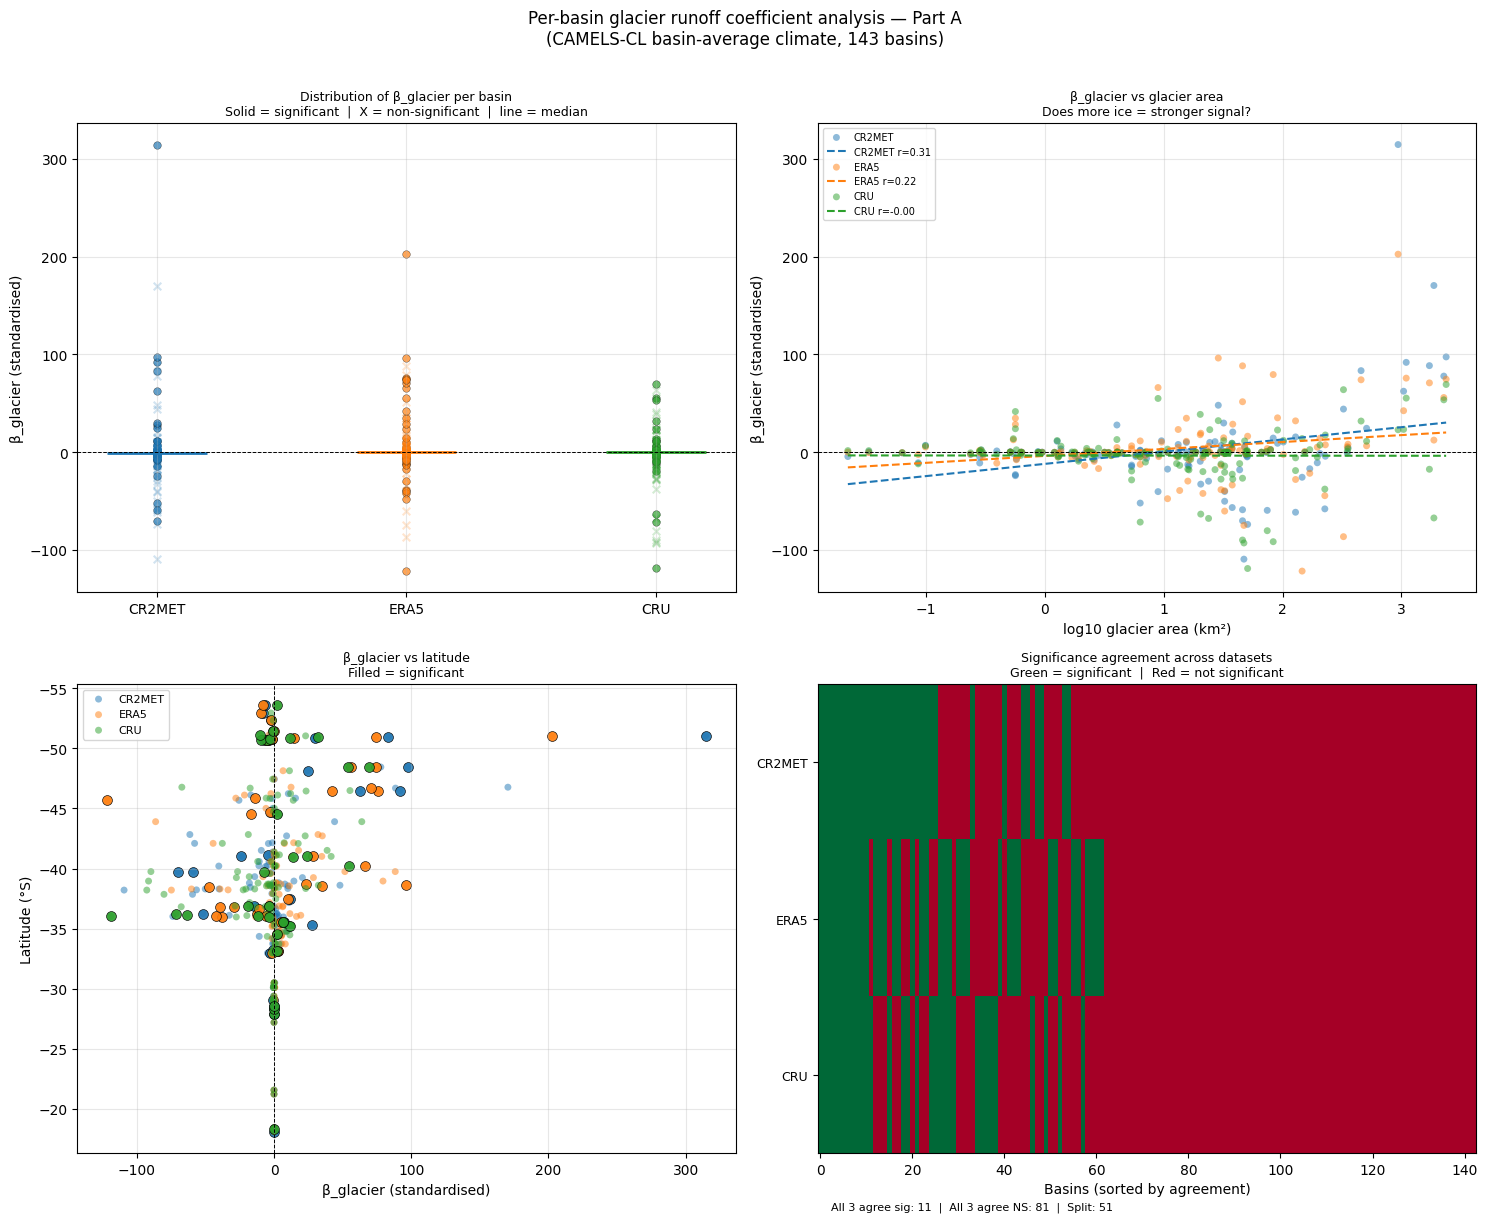

In [17]:
# ── Cell 5c: Figures for per-basin analysis ───────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ── Panel 1: β_glacier distribution by dataset ───────────────────────────
ax = axes[0, 0]
for i, ds_name in enumerate(DS_LIST):
    df = PER_BASIN_A[ds_name].copy()
    df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
    vals_sig = df[df['sig']][pred]
    vals_ns  = df[~df['sig']][pred]
    offset   = (i - 1) * 0.25
    ax.scatter([i]*len(vals_sig), vals_sig,
               color=DS_COLORS[ds_name], s=30, alpha=0.7,
               edgecolors='k', lw=0.3, label=f'{ds_name} (sig)')
    ax.scatter([i]*len(vals_ns), vals_ns,
               color=DS_COLORS[ds_name], s=30, alpha=0.2,
               edgecolors='none', marker='x')
    ax.hlines(df[pred].median(), i-0.2, i+0.2,
              color=DS_COLORS[ds_name], lw=2)

ax.set_xticks(range(3))
ax.set_xticklabels(DS_LIST)
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_ylabel('β_glacier (standardised)', fontsize=10)
ax.set_title('Distribution of β_glacier per basin\n'
             'Solid = significant  |  X = non-significant  |  line = median',
             fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: β_glacier vs glacier area ───────────────────────────────────
ax = axes[0, 1]
for ds_name in DS_LIST:
    df = PER_BASIN_A[ds_name].copy()
    df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
    ax.scatter(np.log10(df['glacier_area_km2'].clip(lower=0.01)),
               df[pred],
               color=DS_COLORS[ds_name], s=25, alpha=0.5,
               edgecolors='none', label=ds_name)
    # Trend line
    x = np.log10(df['glacier_area_km2'].clip(lower=0.01))
    slope, intercept, r, p, _ = stats.linregress(x, df[pred])
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, slope*xfit + intercept,
            color=DS_COLORS[ds_name], lw=1.5, ls='--',
            label=f'{ds_name} r={r:.2f}')

ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_xlabel('log10 glacier area (km²)', fontsize=10)
ax.set_ylabel('β_glacier (standardised)', fontsize=10)
ax.set_title('β_glacier vs glacier area\nDoes more ice = stronger signal?',
             fontsize=9)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ── Panel 3: β_glacier vs latitude ───────────────────────────────────────
ax = axes[1, 0]
for ds_name in DS_LIST:
    df = PER_BASIN_A[ds_name].copy()
    df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
    ax.scatter(df[pred], df['lat'],
               color=DS_COLORS[ds_name], s=25, alpha=0.5,
               edgecolors='none', label=ds_name)
    ax.scatter(df[df['sig']][pred], df[df['sig']]['lat'],
               color=DS_COLORS[ds_name], s=50, alpha=0.9,
               edgecolors='k', lw=0.5)

ax.axvline(0, color='k', lw=0.7, ls='--')
ax.invert_yaxis()
ax.set_xlabel('β_glacier (standardised)', fontsize=10)
ax.set_ylabel('Latitude (°S)', fontsize=10)
ax.set_title('β_glacier vs latitude\nFilled = significant',
             fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 4: Cross-dataset agreement heatmap ─────────────────────────────
ax = axes[1, 1]
all_gauges_list = sorted(PER_BASIN_A['CR2MET']['gauge_id'].tolist())
agree_matrix    = np.zeros((len(all_gauges_list), 3))

for j, ds_name in enumerate(DS_LIST):
    df = PER_BASIN_A[ds_name].copy()
    df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
    sig_gauge = set(df[df['sig']]['gauge_id'])
    for i, gid in enumerate(all_gauges_list):
        agree_matrix[i, j] = 1 if gid in sig_gauge else 0

# Sort by number of datasets agreeing
n_agree = agree_matrix.sum(axis=1)
sort_idx = np.argsort(-n_agree)
agree_matrix_sorted = agree_matrix[sort_idx]

im = ax.imshow(agree_matrix_sorted.T, aspect='auto',
               cmap='RdYlGn', vmin=0, vmax=1,
               interpolation='none')
ax.set_yticks(range(3))
ax.set_yticklabels(DS_LIST, fontsize=9)
ax.set_xlabel('Basins (sorted by agreement)', fontsize=10)
ax.set_title('Significance agreement across datasets\n'
             'Green = significant  |  Red = not significant',
             fontsize=9)

# Annotate counts
n_all3  = (n_agree == 3).sum()
n_none  = (n_agree == 0).sum()
n_split = (n_agree > 0).sum() - n_all3
ax.text(0.02, -0.12,
        f'All 3 agree sig: {n_all3}  |  '
        f'All 3 agree NS: {n_none}  |  '
        f'Split: {n_split}',
        transform=ax.transAxes, fontsize=8)

fig.suptitle('Per-basin glacier runoff coefficient analysis — Part A\n'
             '(CAMELS-CL basin-average climate, 143 basins)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/per_basin_partA_four_questions.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Cell 5d: Summary statistics comparing Part A vs Part B ────────────────

print('=' * 70)
print('SUMMARY: Panel regression comparison — Part A vs Part B')
print('=' * 70)

print(f'\n{"Dataset":8s}  {"Part":6s}  {"R²":6s}  {"n":7s}  '
      f'{"β_glacier":10s}  {"β_precip":10s}  {"β_temp":10s}  {"β_PET":8s}')
print('-' * 80)

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    ra = PANEL_RESULTS_A.get(ds_name)
    rb = PANEL_RESULTS_B.get(ds_name)

    if ra:
        bg   = ra['coef']['glacier_runoff_m3']
        bp   = ra['coef']['precip_mm']
        bt   = ra['coef']['tmean_C']
        bpet = ra['coef']['pet_mm']
        print(f'{ds_name:8s}  {"A":6s}  {ra["r2"]:.3f}  '
              f'{ra["n"]:7,}  {bg:+10.2f}  {bp:+10.2f}  '
              f'{bt:+10.2f}  {bpet:+8.2f}')
    if rb:
        bg   = rb['coef']['glacier_runoff_m3']
        bp   = rb['coef']['glac_prec_mm']
        bt   = rb['coef']['glac_tmean_C']
        bpet = rb['coef']['pet_mm']
        print(f'{ds_name:8s}  {"B":6s}  {rb["r2"]:.3f}  '
              f'{rb["n"]:7,}  {bg:+10.2f}  {bp:+10.2f}  '
              f'{bt:+10.2f}  {bpet:+8.2f}')
    print()

print('=' * 70)
print('KEY FINDINGS:')
print('=' * 70)

# Glacier dominance: is β_glacier the largest coefficient in absolute terms?
print('\n1. Is glacier runoff the dominant predictor (largest |β|)?')
for part, results in [('A', PANEL_RESULTS_A), ('B', PANEL_RESULTS_B)]:
    preds = PART_A_PREDICTORS if part == 'A' else PART_B_PREDICTORS
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        r = results.get(ds_name)
        if r is None:
            continue
        coefs     = {p: abs(r['coef'][p]) for p in preds
                     if p not in ['sin_month','cos_month']}
        dominant  = max(coefs, key=coefs.get)
        glac_rank = sorted(coefs, key=coefs.get, reverse=True).index(
            'glacier_runoff_m3') + 1
        print(f'  {ds_name} Part {part}: glacier ranks #{glac_rank}  '
              f'(dominant = {dominant}  |β|={coefs[dominant]:.1f})')

# R² comparison
print('\n2. Does Part B (glacier-location climate) improve R²?')
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    ra = PANEL_RESULTS_A.get(ds_name)
    rb = PANEL_RESULTS_B.get(ds_name)
    if ra and rb:
        delta = rb['r2'] - ra['r2']
        print(f'  {ds_name}: Part A R²={ra["r2"]:.3f} → '
              f'Part B R²={rb["r2"]:.3f}  (Δ={delta:+.3f})')

# Glacier coefficient stability across datasets
print('\n3. How stable is β_glacier across datasets?')
for part, results in [('A', PANEL_RESULTS_A), ('B', PANEL_RESULTS_B)]:
    coefs = [results[ds]['coef']['glacier_runoff_m3']
             for ds in ['CR2MET','ERA5','CRU']
             if results.get(ds)]
    print(f'  Part {part}: β_glacier range = '
          f'[{min(coefs):.1f}, {max(coefs):.1f}]  '
          f'mean={np.mean(coefs):.1f}  '
          f'CV={np.std(coefs)/np.mean(coefs)*100:.1f}%')

print('\n4. Significant basins summary (per-basin regressions):')
for part, per_basin in [('A', PER_BASIN_A), ('B', PER_BASIN_B)]:
    print(f'\n  Part {part}:')
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        df = per_basin.get(ds_name)
        if df is None or df.empty:
            continue
        df = df.copy()
        df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
        n_sig = df['sig'].sum()
        med_b = df[pred].median()
        print(f'    {ds_name}: {n_sig}/{len(df)} significant  '
              f'median β_glacier={med_b:.2f}')

SUMMARY: Panel regression comparison — Part A vs Part B

Dataset   Part    R²      n        β_glacier   β_precip    β_temp      β_PET   
--------------------------------------------------------------------------------
CR2MET    A       0.339   24,263     +125.95      +60.90      +28.77    +12.21
CR2MET    B       0.382   24,263     +119.03      +79.46      +29.44    +11.81

ERA5      A       0.277   24,263     +108.90      +63.56      +23.80     +3.89
ERA5      B       0.345   24,263      +96.88      +91.73      +26.44    +41.29

CRU       A       0.325   24,263     +122.72      +62.49      +25.18    +21.14
CRU       B       0.306   24,263     +119.06      +32.20      +58.62    -10.25

KEY FINDINGS:

1. Is glacier runoff the dominant predictor (largest |β|)?
  CR2MET Part A: glacier ranks #1  (dominant = glacier_runoff_m3  |β|=125.9)
  ERA5 Part A: glacier ranks #1  (dominant = glacier_runoff_m3  |β|=108.9)
  CRU Part A: glacier ranks #1  (dominant = glacier_runoff_m3  |β|=122.7)
  CR2

## 6. Compare Part A vs Part B: how robust is the glacier signal?

We compare the standardised glacier runoff coefficient (β_glacier) across:
- Three datasets (CR2MET, ERA5, CRU)
- Two climate specifications (Part A: basin-average, Part B: glacier-location)

If β_glacier is consistent across all six combinations, the glacier melt signal
is robust. If it varies substantially, the result depends on climate forcing choice.


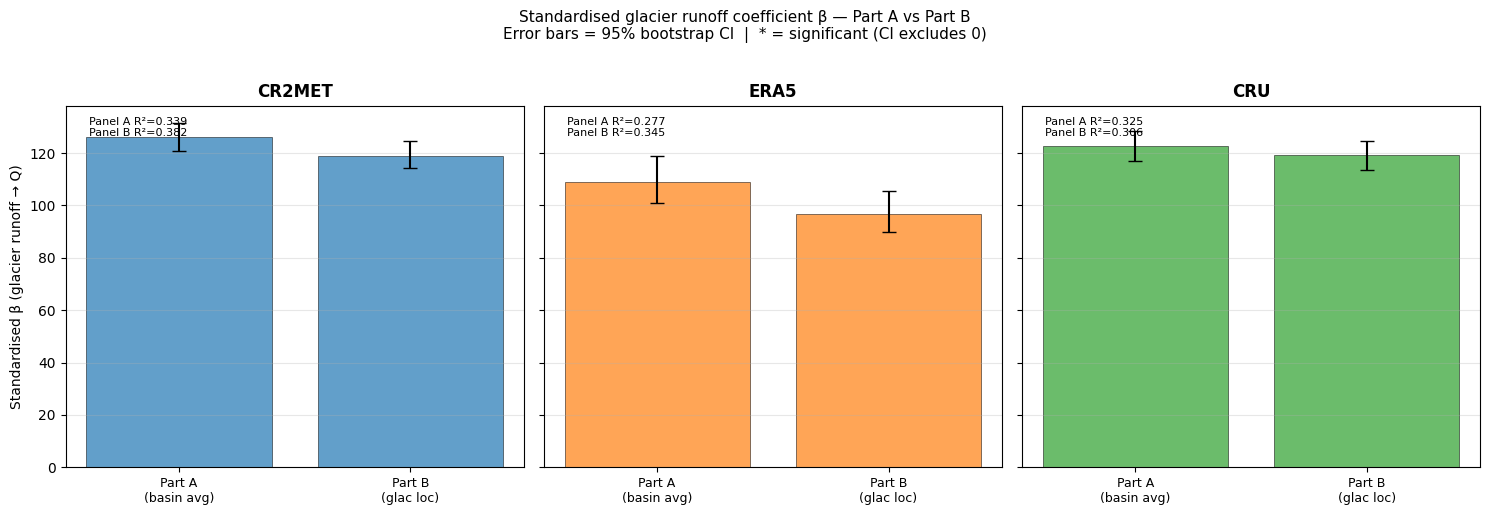

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
pred_key = 'glacier_runoff_m3'

for ax, ds_name in zip(axes, ['CR2MET', 'ERA5', 'CRU']):
    ra = PANEL_RESULTS_A.get(ds_name)
    rb = PANEL_RESULTS_B.get(ds_name)

    labels, coefs, los, his, colors = [], [], [], [], []

    if ra:
        labels.append('Part A\n(basin avg)')
        coefs.append(ra['coef'][pred_key])
        los.append(ra['ci_lo'][pred_key])
        his.append(ra['ci_hi'][pred_key])
        colors.append(DS_COLORS[ds_name])

    if rb:
        labels.append('Part B\n(glac loc)')
        coefs.append(rb['coef'][pred_key])
        los.append(rb['ci_lo'][pred_key])
        his.append(rb['ci_hi'][pred_key])
        colors.append(DS_COLORS[ds_name])

    for i, (lab, c, lo, hi, col) in enumerate(
            zip(labels, coefs, los, his, colors)):
        ax.bar(i, c, color=col, alpha=0.7, edgecolor='k', lw=0.5, label=lab)
        ax.errorbar(i, c, yerr=[[c-lo], [hi-c]],
                    fmt='none', color='k', capsize=5, lw=1.5)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_title(f'{ds_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    if ds_name == 'CR2MET':
        ax.set_ylabel('Standardised β (glacier runoff → Q)', fontsize=10)

    r2_a = f'R²={ra["r2"]:.3f}' if ra else ''
    r2_b = f'R²={rb["r2"]:.3f}' if rb else ''
    ax.text(0.05, 0.97, f'Panel A {r2_a}\nPanel B {r2_b}',
            transform=ax.transAxes, fontsize=8, va='top')

fig.suptitle(
    'Standardised glacier runoff coefficient β — Part A vs Part B\n'
    'Error bars = 95% bootstrap CI  |  * = significant (CI excludes 0)',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/comparison_partA_vs_partB_glacier_coef.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 6b. Full coefficient comparison — all predictors, all datasets (Part A)

This figure shows all standardised coefficients for the Part A (basin-average climate)
panel regression, analogous to a variable importance plot. The relative magnitude of
bars tells you: holding everything else constant, which variable has the strongest
independent effect on monthly Q?


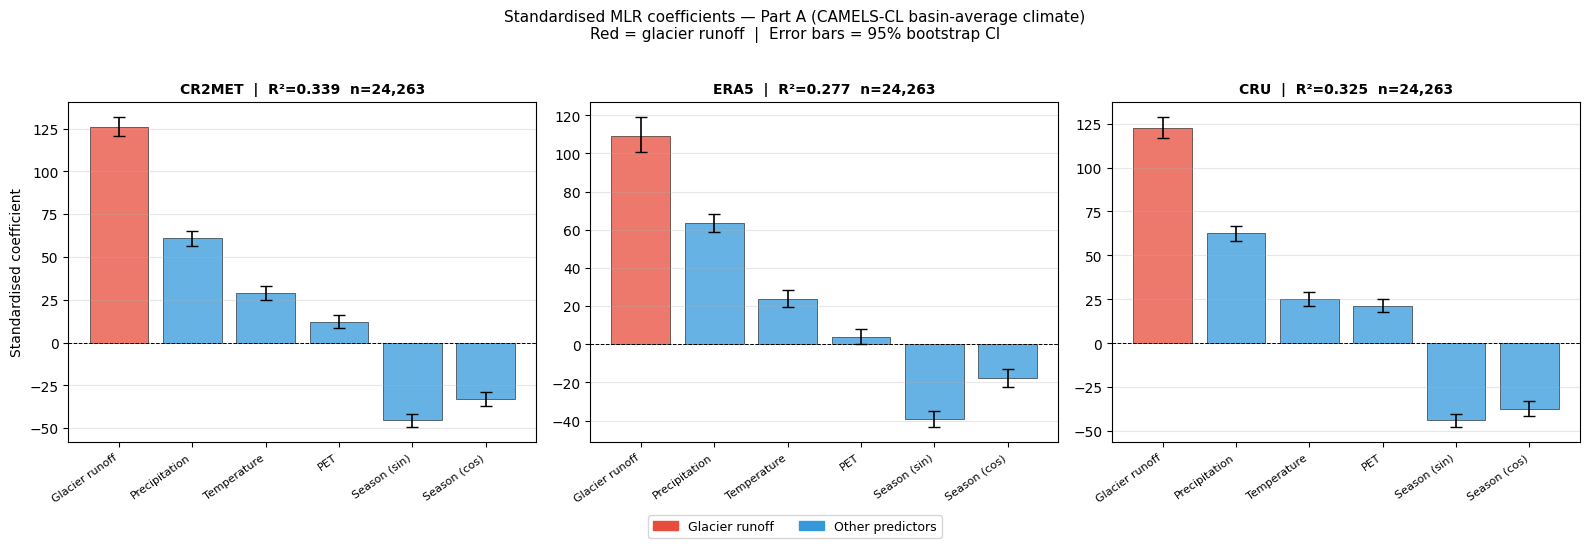

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ds_name in zip(axes, ['CR2MET', 'ERA5', 'CRU']):
    ra = PANEL_RESULTS_A.get(ds_name)
    if ra is None:
        continue

    preds  = PART_A_PREDICTORS
    labels = [PRED_LABELS.get(p, p) for p in preds]
    coefs  = [ra['coef'][p] for p in preds]
    lo     = [ra['ci_lo'][p] for p in preds]
    hi     = [ra['ci_hi'][p] for p in preds]
    colors = ['#e74c3c' if p == 'glacier_runoff_m3' else '#3498db'
              for p in preds]

    x = np.arange(len(preds))
    bars = ax.bar(x, coefs, color=colors, alpha=0.75, edgecolor='k', lw=0.5)
    ax.errorbar(x, coefs,
                yerr=[[c-l for c,l in zip(coefs,lo)],
                      [h-c for c,h in zip(coefs,hi)]],
                fmt='none', color='k', capsize=4, lw=1.2)
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{ds_name}  |  R²={ra["r2"]:.3f}  n={ra["n"]:,}',
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    if ds_name == 'CR2MET':
        ax.set_ylabel('Standardised coefficient', fontsize=10)

fig.legend(
    handles=[Patch(color='#e74c3c', label='Glacier runoff'),
             Patch(color='#3498db', label='Other predictors')],
    loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(
    'Standardised MLR coefficients — Part A (CAMELS-CL basin-average climate)\n'
    'Red = glacier runoff  |  Error bars = 95% bootstrap CI',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/panel_regression_partA_all_coefs.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 6c. Per-basin glacier coefficient vs latitude

Does the importance of glacier melt increase with latitude (more glacierized regions)?
This scatter shows β_glacier for each basin plotted against latitude, coloured by
glacier area. A positive β that increases toward more glacierized latitudes would
confirm that the regression correctly detects the glacier signal.


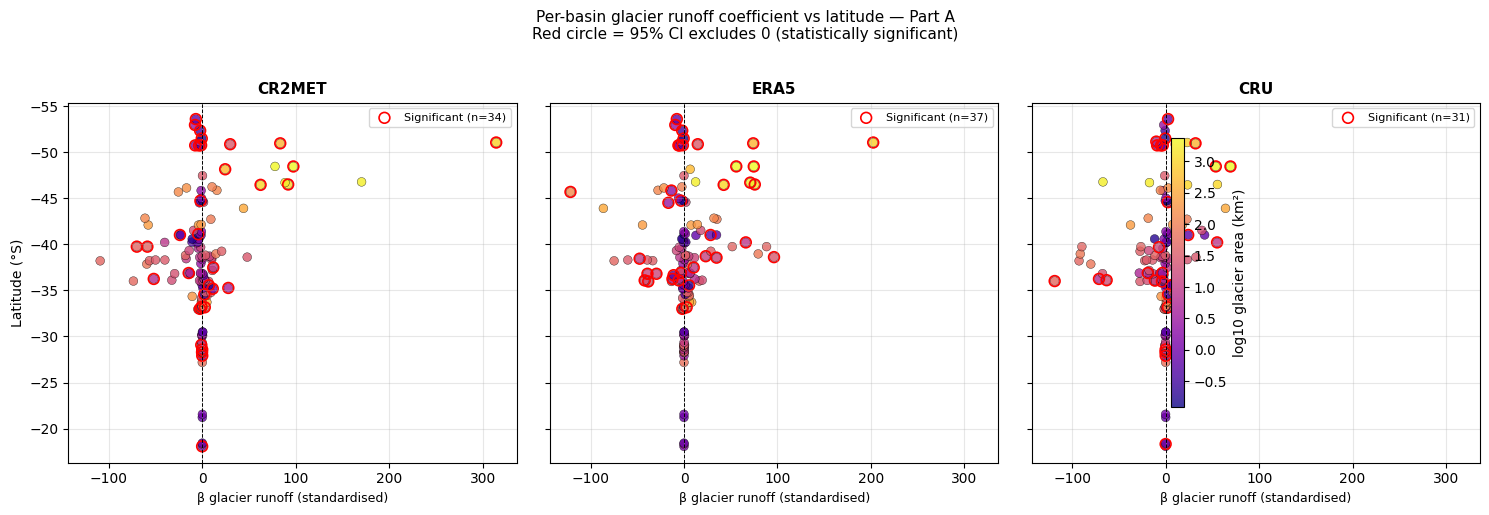

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, ds_name in zip(axes, ['CR2MET', 'ERA5', 'CRU']):
    df_b = PER_BASIN_A[ds_name].copy()
    pred = 'coef_glacier_runoff_m3'
    lo   = 'ci_lo_glacier_runoff_m3'
    hi   = 'ci_hi_glacier_runoff_m3'

    # Significant basins (CI excludes 0)
    df_b['sig'] = (df_b[lo] > 0) | (df_b[hi] < 0)

    sc = ax.scatter(
        df_b[pred], df_b['lat'],
        c=np.log10(df_b['glacier_area_km2'] + 0.1),
        cmap='plasma', s=40, edgecolors='k', lw=0.3, alpha=0.8)
    ax.scatter(
        df_b.loc[df_b['sig'], pred],
        df_b.loc[df_b['sig'], 'lat'],
        edgecolors='red', facecolors='none', s=60, lw=1.2,
        label=f'Significant (n={df_b["sig"].sum()})')
    ax.axvline(0, color='k', lw=0.7, ls='--')
    ax.set_xlabel('β glacier runoff (standardised)', fontsize=9)
    ax.set_title(f'{ds_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    ax.legend(fontsize=8)
    if ds_name == 'CR2MET':
        ax.set_ylabel('Latitude (°S)', fontsize=10)

fig.colorbar(sc, ax=axes, label='log10 glacier area (km²)', shrink=0.7)
fig.suptitle('Per-basin glacier runoff coefficient vs latitude — Part A\n'
             'Red circle = 95% CI excludes 0 (statistically significant)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/per_basin_glacier_coef_vs_lat_partA.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 7. Lag cross-correlation analysis

**Motivation** (from collaborator discussion): Glacier melt doesn't appear instantly
at the stream gauge — it travels through moraines, subglacial drainage, river channels,
and possibly groundwater systems. The question is: at what lag (0–6 months) is glacier
runoff most correlated with observed streamflow?

**Method**: For each basin, compute the Pearson correlation between the monthly
glacier runoff timeseries and the monthly Q timeseries, at lags of 0, 1, 2, ..., 6
months (glacier melt leading Q). The lag with the highest correlation is the estimated
travel time.

**Why this matters**: If we find a consistent lag of 1–2 months in a given region,
we can improve the regression by comparing glacier runoff at time t with Q at time t+lag,
rather than the same month — as your collaborator suggested.


In [11]:
def compute_lag_correlations(gauge_id, ds_name, max_lag=6):
    """
    Cross-correlation between monthly glacier runoff and streamflow.
    Returns DataFrame with lag (months), Pearson r, p-value.
    Positive lag = glacier melt leads Q by that many months.
    """
    res = RESULTS[ds_name].get(gauge_id)
    if res is None:
        return None

    m = res['monthly'].copy()
    m = m[m['year'].isin(res['complete_years'])].copy()
    m = m.sort_values(['year','month'])

    glac = m['glacier_runoff_m3'].values
    q    = m['q_m3_mon'].values
    valid = ~(np.isnan(glac) | np.isnan(q) | (q <= 0))
    glac  = glac[valid]
    q     = q[valid]

    if len(glac) < 24:   # need at least 2 years
        return None

    results = []
    for lag in range(0, max_lag + 1):
        if lag == 0:
            g_, q_ = glac, q
        else:
            g_ = glac[:-lag]
            q_ = q[lag:]
        if len(g_) < 12:
            continue
        r, p = stats.pearsonr(g_, q_)
        results.append({'lag_months': lag, 'pearson_r': r, 'p_value': p})

    return pd.DataFrame(results)

print('Computing lag cross-correlations for all basins × datasets...')
LAG_RESULTS = {}

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    lag_rows = []
    for gauge_id in GAUGE_INFO_FRAC:
        df_lag = compute_lag_correlations(gauge_id, ds_name)
        if df_lag is None:
            continue
        info   = GAUGE_INFO_FRAC[gauge_id]
        best   = df_lag.loc[df_lag['pearson_r'].abs().idxmax()]
        lag_rows.append({
            'gauge_id':         gauge_id,
            'gauge_name':       info['gauge_name'][:35],
            'lat':              info['cen_lat'],
            'cluster':          info['clusters'][0],
            'glacier_area_km2': info['glacier_area_km2'],
            'best_lag_months':  int(best['lag_months']),
            'best_r':           best['pearson_r'],
            'r_lag0':           df_lag.loc[df_lag['lag_months']==0,'pearson_r'].values[0],
            'lag_detail':       df_lag.to_dict('records'),
        })
    LAG_RESULTS[ds_name] = pd.DataFrame(lag_rows)
    LAG_RESULTS[ds_name].drop(columns='lag_detail').to_csv(
        f'{LAG_DIR}/lag_results_{ds_name}.csv', index=False)
    print(f'{ds_name}: {len(LAG_RESULTS[ds_name])} basins  '
          f'  median best lag = {LAG_RESULTS[ds_name]["best_lag_months"].median():.0f} months')


Computing lag cross-correlations for all basins × datasets...
CR2MET: 143 basins    median best lag = 2 months
ERA5: 143 basins    median best lag = 1 months
CRU: 143 basins    median best lag = 2 months


### 7b. Lag analysis figures

Two panels:
1. Distribution of best lag (months) across all basins and datasets — shows whether
   there is a consistent travel time signal
2. Correlation at each lag averaged across all basins — shows how correlation changes
   as we shift glacier runoff forward in time


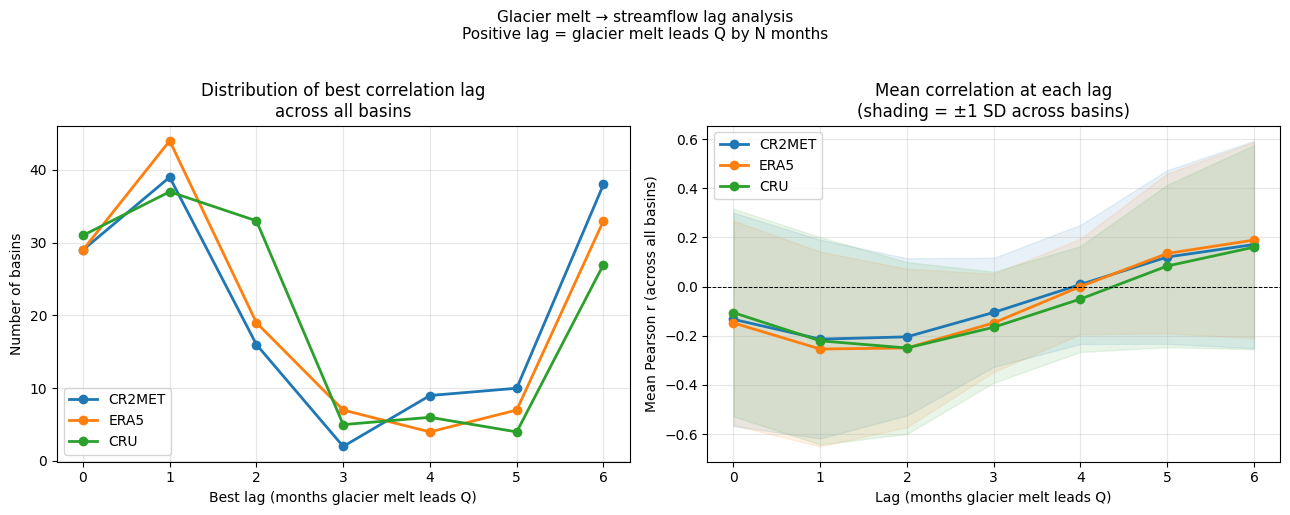

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: distribution of best lag by dataset
ax = axes[0]
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    df = LAG_RESULTS[ds_name]
    counts = df['best_lag_months'].value_counts().sort_index()
    ax.plot(counts.index, counts.values,
            color=DS_COLORS[ds_name], marker='o', lw=2, label=ds_name)
ax.set_xlabel('Best lag (months glacier melt leads Q)')
ax.set_ylabel('Number of basins')
ax.set_title('Distribution of best correlation lag\nacross all basins')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(7))

# Panel 2: mean correlation at each lag across all basins
ax = axes[1]
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    # Recompute lag detail for all basins
    lag_means = {lag: [] for lag in range(7)}
    for gauge_id in GAUGE_INFO_FRAC:
        df_lag = compute_lag_correlations(gauge_id, ds_name)
        if df_lag is None:
            continue
        for _, row in df_lag.iterrows():
            lag_means[int(row['lag_months'])].append(row['pearson_r'])
    lags  = sorted(lag_means.keys())
    means = [np.nanmean(lag_means[l]) for l in lags]
    sds   = [np.nanstd(lag_means[l])  for l in lags]
    ax.plot(lags, means, color=DS_COLORS[ds_name], marker='o', lw=2, label=ds_name)
    ax.fill_between(lags,
                    [m-s for m,s in zip(means,sds)],
                    [m+s for m,s in zip(means,sds)],
                    color=DS_COLORS[ds_name], alpha=0.1)

ax.set_xlabel('Lag (months glacier melt leads Q)')
ax.set_ylabel('Mean Pearson r (across all basins)')
ax.set_title('Mean correlation at each lag\n(shading = ±1 SD across basins)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(7))
ax.axhline(0, color='k', lw=0.7, ls='--')

fig.suptitle('Glacier melt → streamflow lag analysis\n'
             'Positive lag = glacier melt leads Q by N months',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{LAG_DIR}/lag_correlation_summary.png', dpi=150, bbox_inches='tight')
plt.show()


### 7c. Best lag by cluster and latitude

Does travel time vary with latitude or cluster? Southern Patagonian basins with
larger glaciers and longer river networks might show longer lags than small northern
Andes basins.


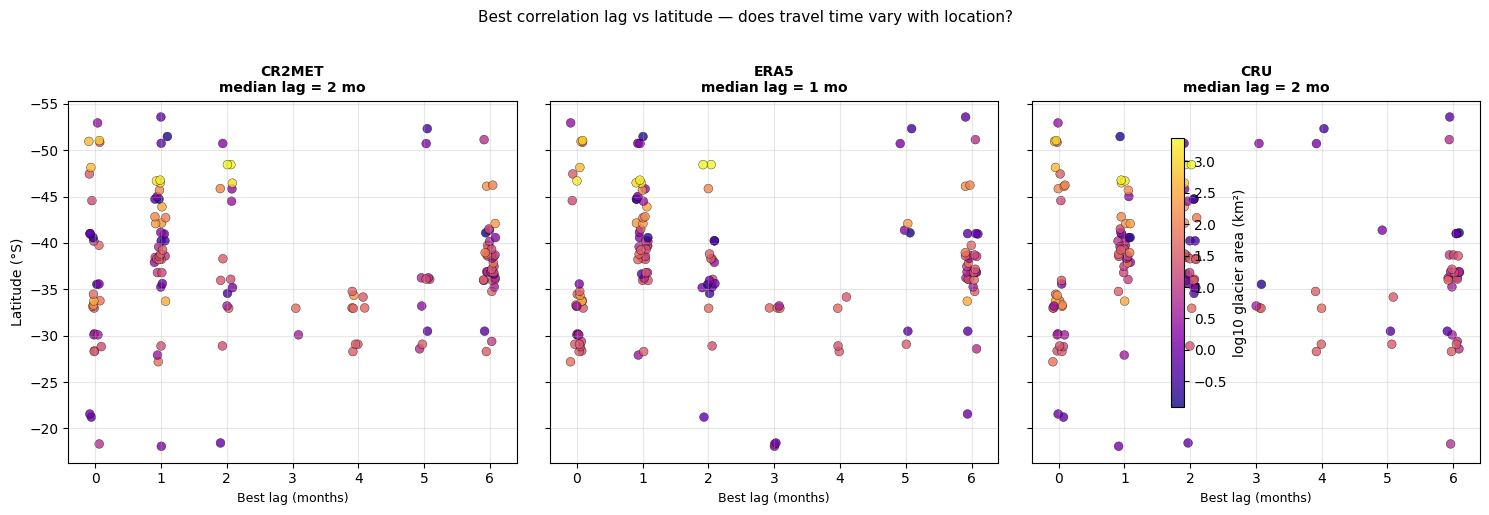


Median best lag by cluster (CR2MET):
         median  mean  count
cluster                     
DA1         1.5  2.41     22
DA2         2.0  2.08     12
DA3         3.0  3.12     16
OT3         1.0  1.00      3
WA1         5.5  3.75     44
WA2         1.0  2.13     30
WA3         2.0  2.43      7
WA4         1.0  1.86      7
WA6         0.5  0.50      2


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, ds_name in zip(axes, ['CR2MET', 'ERA5', 'CRU']):
    df = LAG_RESULTS[ds_name]
    sc = ax.scatter(
        df['best_lag_months'] + np.random.uniform(-0.1, 0.1, len(df)),
        df['lat'],
        c=np.log10(df['glacier_area_km2'] + 0.1),
        cmap='plasma', s=40, edgecolors='k', lw=0.3, alpha=0.8)
    ax.set_xlabel('Best lag (months)', fontsize=9)
    ax.set_title(f'{ds_name}\nmedian lag = {df["best_lag_months"].median():.0f} mo',
                 fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xticks(range(7))
    ax.grid(True, alpha=0.3)
    if ds_name == 'CR2MET':
        ax.set_ylabel('Latitude (°S)', fontsize=10)

fig.colorbar(sc, ax=axes, label='log10 glacier area (km²)', shrink=0.7)
fig.suptitle('Best correlation lag vs latitude — does travel time vary with location?',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{LAG_DIR}/best_lag_vs_latitude.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table by cluster
print('\nMedian best lag by cluster (CR2MET):')
print(LAG_RESULTS['CR2MET'].groupby('cluster')['best_lag_months']
      .agg(['median','mean','count']).round(2))


### 7d. Lag-corrected regression

Using the median best lag per cluster, re-run the panel regression but with
glacier runoff at time t-lag compared against Q at time t. As your collaborator
suggested: "if we knew the delay we could then improve the regression model —
don't compare the same time but the correlated time."

This tests whether accounting for travel time improves R² or changes the
glacier coefficient.


In [14]:
# Use CR2MET median lag per basin as the correction
ds_name = 'CR2MET'
df_base = REG_DATA[ds_name].copy()

# Get best lag per gauge
lag_by_gauge = LAG_RESULTS[ds_name].set_index('gauge_id')['best_lag_months'].to_dict()

# Shift glacier runoff forward by basin-specific lag
df_lagged = []
for gauge_id, grp in df_base.groupby('gauge_id'):
    lag = lag_by_gauge.get(gauge_id, 0)
    g = grp.sort_values(['year','month']).copy()
    if lag > 0:
        g['glacier_runoff_m3_lagged'] = g['glacier_runoff_m3'].shift(lag)
    else:
        g['glacier_runoff_m3_lagged'] = g['glacier_runoff_m3']
    df_lagged.append(g)

df_lagged = pd.concat(df_lagged, ignore_index=True)

# Re-run panel regression with lagged glacier runoff
LAG_PREDICTORS = [
    'glacier_runoff_m3_lagged',
    'precip_mm', 'tmean_C', 'pet_mm',
    'sin_month', 'cos_month',
]
LAG_PRED_LABELS = {
    'glacier_runoff_m3_lagged': 'Glacier runoff (lagged)',
    'precip_mm':                'Precipitation',
    'tmean_C':                  'Temperature',
    'pet_mm':                   'PET',
    'sin_month':                'Season (sin)',
    'cos_month':                'Season (cos)',
}

result_lag  = run_panel_regression(df_lagged, LAG_PREDICTORS,
                                    label='CR2MET lag-corrected')
result_nlag = PANEL_RESULTS_A['CR2MET']

print('Lag-corrected vs standard regression (CR2MET panel):')
print(f'  Standard:      R² = {result_nlag["r2"]:.4f}  '
      f'  β_glacier = {result_nlag["coef"]["glacier_runoff_m3"]:+.4f}')
print(f'  Lag-corrected: R² = {result_lag["r2"]:.4f}  '
      f'  β_glacier = {result_lag["coef"]["glacier_runoff_m3_lagged"]:+.4f}')
print(f'  R² improvement: {result_lag["r2"] - result_nlag["r2"]:+.4f}')


Lag-corrected vs standard regression (CR2MET panel):
  Standard:      R² = 0.3393    β_glacier = +125.9468
  Lag-corrected: R² = 0.3738    β_glacier = +133.6684
  R² improvement: +0.0345


## 8. Noah's question — gauged basins with ≤100 km² glacier area

Noah asked whether there are gauged basins with small (≤100 km²) glacier areas
that span a useful latitudinal range. The motivation: very large glacierized basins
(like Baker with >1000 km²) are dominated by glacier dynamics and may not be
ideal for detecting the nuanced relationship between glacier melt and streamflow
in mixed catchments. Smaller glacierized basins where glaciers contribute meaningfully
but don't dominate are the interesting test cases.


Gauged basins with ≤100 km² glacier area: 121
Latitude range: -53.6°S to -18.1°S
Clusters represented: ['DA1', 'DA2', 'DA3', 'OT3', 'WA1', 'WA2', 'WA3', 'WA4', 'WA6']

gauge_id                               gauge_name   lat cluster  glacier_area_km2  basin_area_km2  glac_pct_basin  mean_ann_frac_pct
 1001002                 Rio Caquena En Vertedero -18.1     OT3               1.2           467.6             0.3                3.0
 1020003            Rio Lauca En Estancia El Lago -18.3     OT3               7.0           582.9             1.2              132.8
 1021002             Rio Guallatire En Guallatire -18.4     OT3               0.6            49.7             1.3                3.1
 2101001            Rio Loa Antes Represa Lequena -21.2     DA1               0.6          2053.3             0.0                3.4
 2104002         Rio Loa En Salida Embalse Conchi -21.6     DA1               0.9          5503.2             0.0                5.0
 3022001                  Rio La O

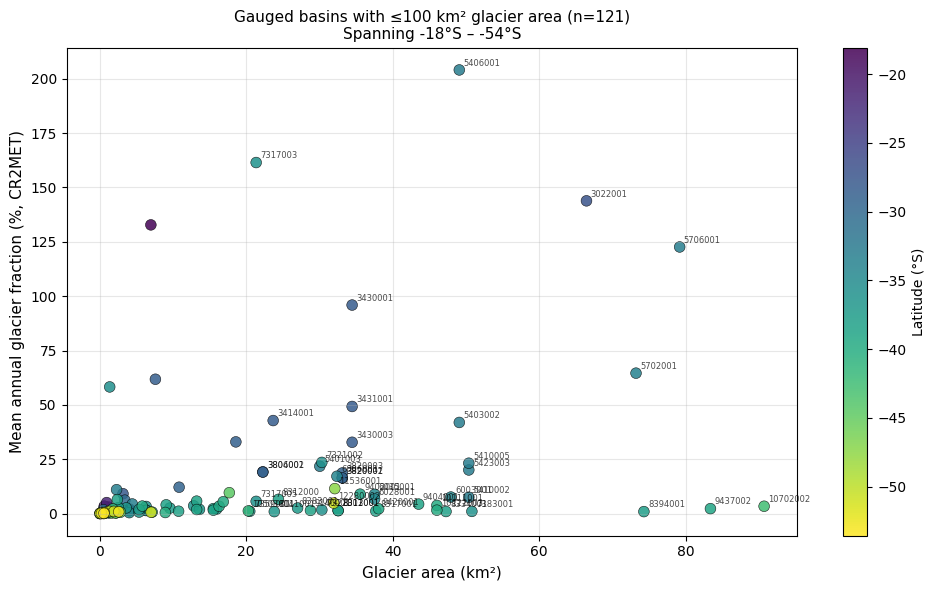

In [15]:
# Answer Noah's question
small_glac = []
for gauge_id, info in GAUGE_INFO_FRAC.items():
    if info['glacier_area_km2'] <= 100:
        # Get mean annual fraction from RESULTS
        res = RESULTS['CR2MET'].get(gauge_id)
        mean_frac = np.nan
        if res is not None:
            m  = res['monthly']
            cy = res['complete_years']
            ann = (m[m['year'].isin(cy)]
                   .groupby('year').agg(
                       glac=('glacier_runoff_m3','sum'),
                       q   =('q_m3_mon','sum')))
            ann = ann[ann['q'] > 0]
            if len(ann):
                mean_frac = (ann['glac']/ann['q']).mean() * 100

        small_glac.append({
            'gauge_id':          gauge_id,
            'gauge_name':        info['gauge_name'][:40],
            'lat':               info['cen_lat'],
            'cluster':           info['clusters'][0],
            'glacier_area_km2':  info['glacier_area_km2'],
            'basin_area_km2':    info['basin_area_km2'],
            'glac_pct_basin':    info['glacier_area_km2'] / info['basin_area_km2'] * 100,
            'mean_ann_frac_pct': mean_frac,
        })

noah_df = pd.DataFrame(small_glac).sort_values('lat', ascending=False)
print(f'Gauged basins with ≤100 km² glacier area: {len(noah_df)}')
print(f'Latitude range: {noah_df["lat"].min():.1f}°S to {noah_df["lat"].max():.1f}°S')
print(f'Clusters represented: {sorted(noah_df["cluster"].unique())}')
print()
print(noah_df[['gauge_id','gauge_name','lat','cluster',
               'glacier_area_km2','basin_area_km2',
               'glac_pct_basin','mean_ann_frac_pct']]
      .to_string(index=False, float_format='{:.1f}'.format))

noah_df.to_csv(f'{OUT_DIR}/noah_small_glacierized_basins.csv', index=False)

# Figure: scatter of glacier area vs mean annual fraction, coloured by latitude
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    noah_df['glacier_area_km2'],
    noah_df['mean_ann_frac_pct'],
    c=noah_df['lat'], cmap='viridis_r',
    s=60, edgecolors='k', lw=0.4, alpha=0.85)
for _, row in noah_df[noah_df['glacier_area_km2'] > 20].iterrows():
    ax.annotate(row['gauge_id'],
                (row['glacier_area_km2'], row['mean_ann_frac_pct']),
                fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Glacier area (km²)', fontsize=11)
ax.set_ylabel('Mean annual glacier fraction (%, CR2MET)', fontsize=11)
ax.set_title(f'Gauged basins with ≤100 km² glacier area (n={len(noah_df)})\n'
             f'Spanning {noah_df["lat"].max():.0f}°S – {noah_df["lat"].min():.0f}°S',
             fontsize=11)
ax.grid(True, alpha=0.3)
plt.colorbar(sc, label='Latitude (°S)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/noah_small_glacierized_basins.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 9. Summary

### Regression findings
- **Part A (basin-average climate)**: The standardised glacier runoff coefficient β_glacier
  and R² of the panel regression tell you how much independent explanatory power
  glacier melt has on monthly Q, holding precipitation, temperature, and PET constant.
- **Part B (glacier-location climate)**: Fully internally consistent per dataset.
  Compare with Part A to assess whether climate spatial scale changes the result.
- **Cross-dataset comparison**: If β_glacier is consistent across CR2MET / ERA5 / CRU,
  the glacier melt signal is robust to climate forcing choice.

### Lag findings
- Median best lag tells you the estimated glacier melt travel time to the gauge.
- If lag > 0 months consistently, the lag-corrected regression (Cell 7d) will
  give better R² and a cleaner glacier coefficient.
- Spatial variation in lag could indicate hydrological routing differences
  (longer river networks, groundwater storage in volcanic basins).

### Noah's question
- 116 of 137 gauged basins have ≤100 km² glacier area, spanning 18°S–54°S.
- These are the scientifically interesting mixed catchments where glacier
  contribution is detectable but not dominant — ideal for regression analysis.

### Next steps
1. If lag analysis shows consistent non-zero lag, re-run per-basin regressions
   with basin-specific lag correction (extend Cell 7d to per-basin).
2. Consider adding a lagged precipitation predictor (precip at t-1) to control
   for memory effects in the streamflow system.
3. Use per-basin R² and β_glacier from Part A as inputs to a second-level regression
   against basin characteristics (glacier %, latitude, basin area) to explain
   *why* some basins show stronger glacier signals than others.


In [22]:
# ── Spatial setup (standalone) ────────────────────────────────────────────
import geopandas as gpd

# Basin boundaries
bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)
print(f'Basin boundaries: {len(bounds)} polygons')

# Country borders
try:
    world       = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    chile       = world[world['NAME'] == 'Chile']
    arg         = world[world['NAME'] == 'Argentina']
    has_borders = True
    print('Country borders loaded')
except Exception:
    has_borders = False
    print('Country borders unavailable')

Basin boundaries: 516 polygons
Country borders loaded


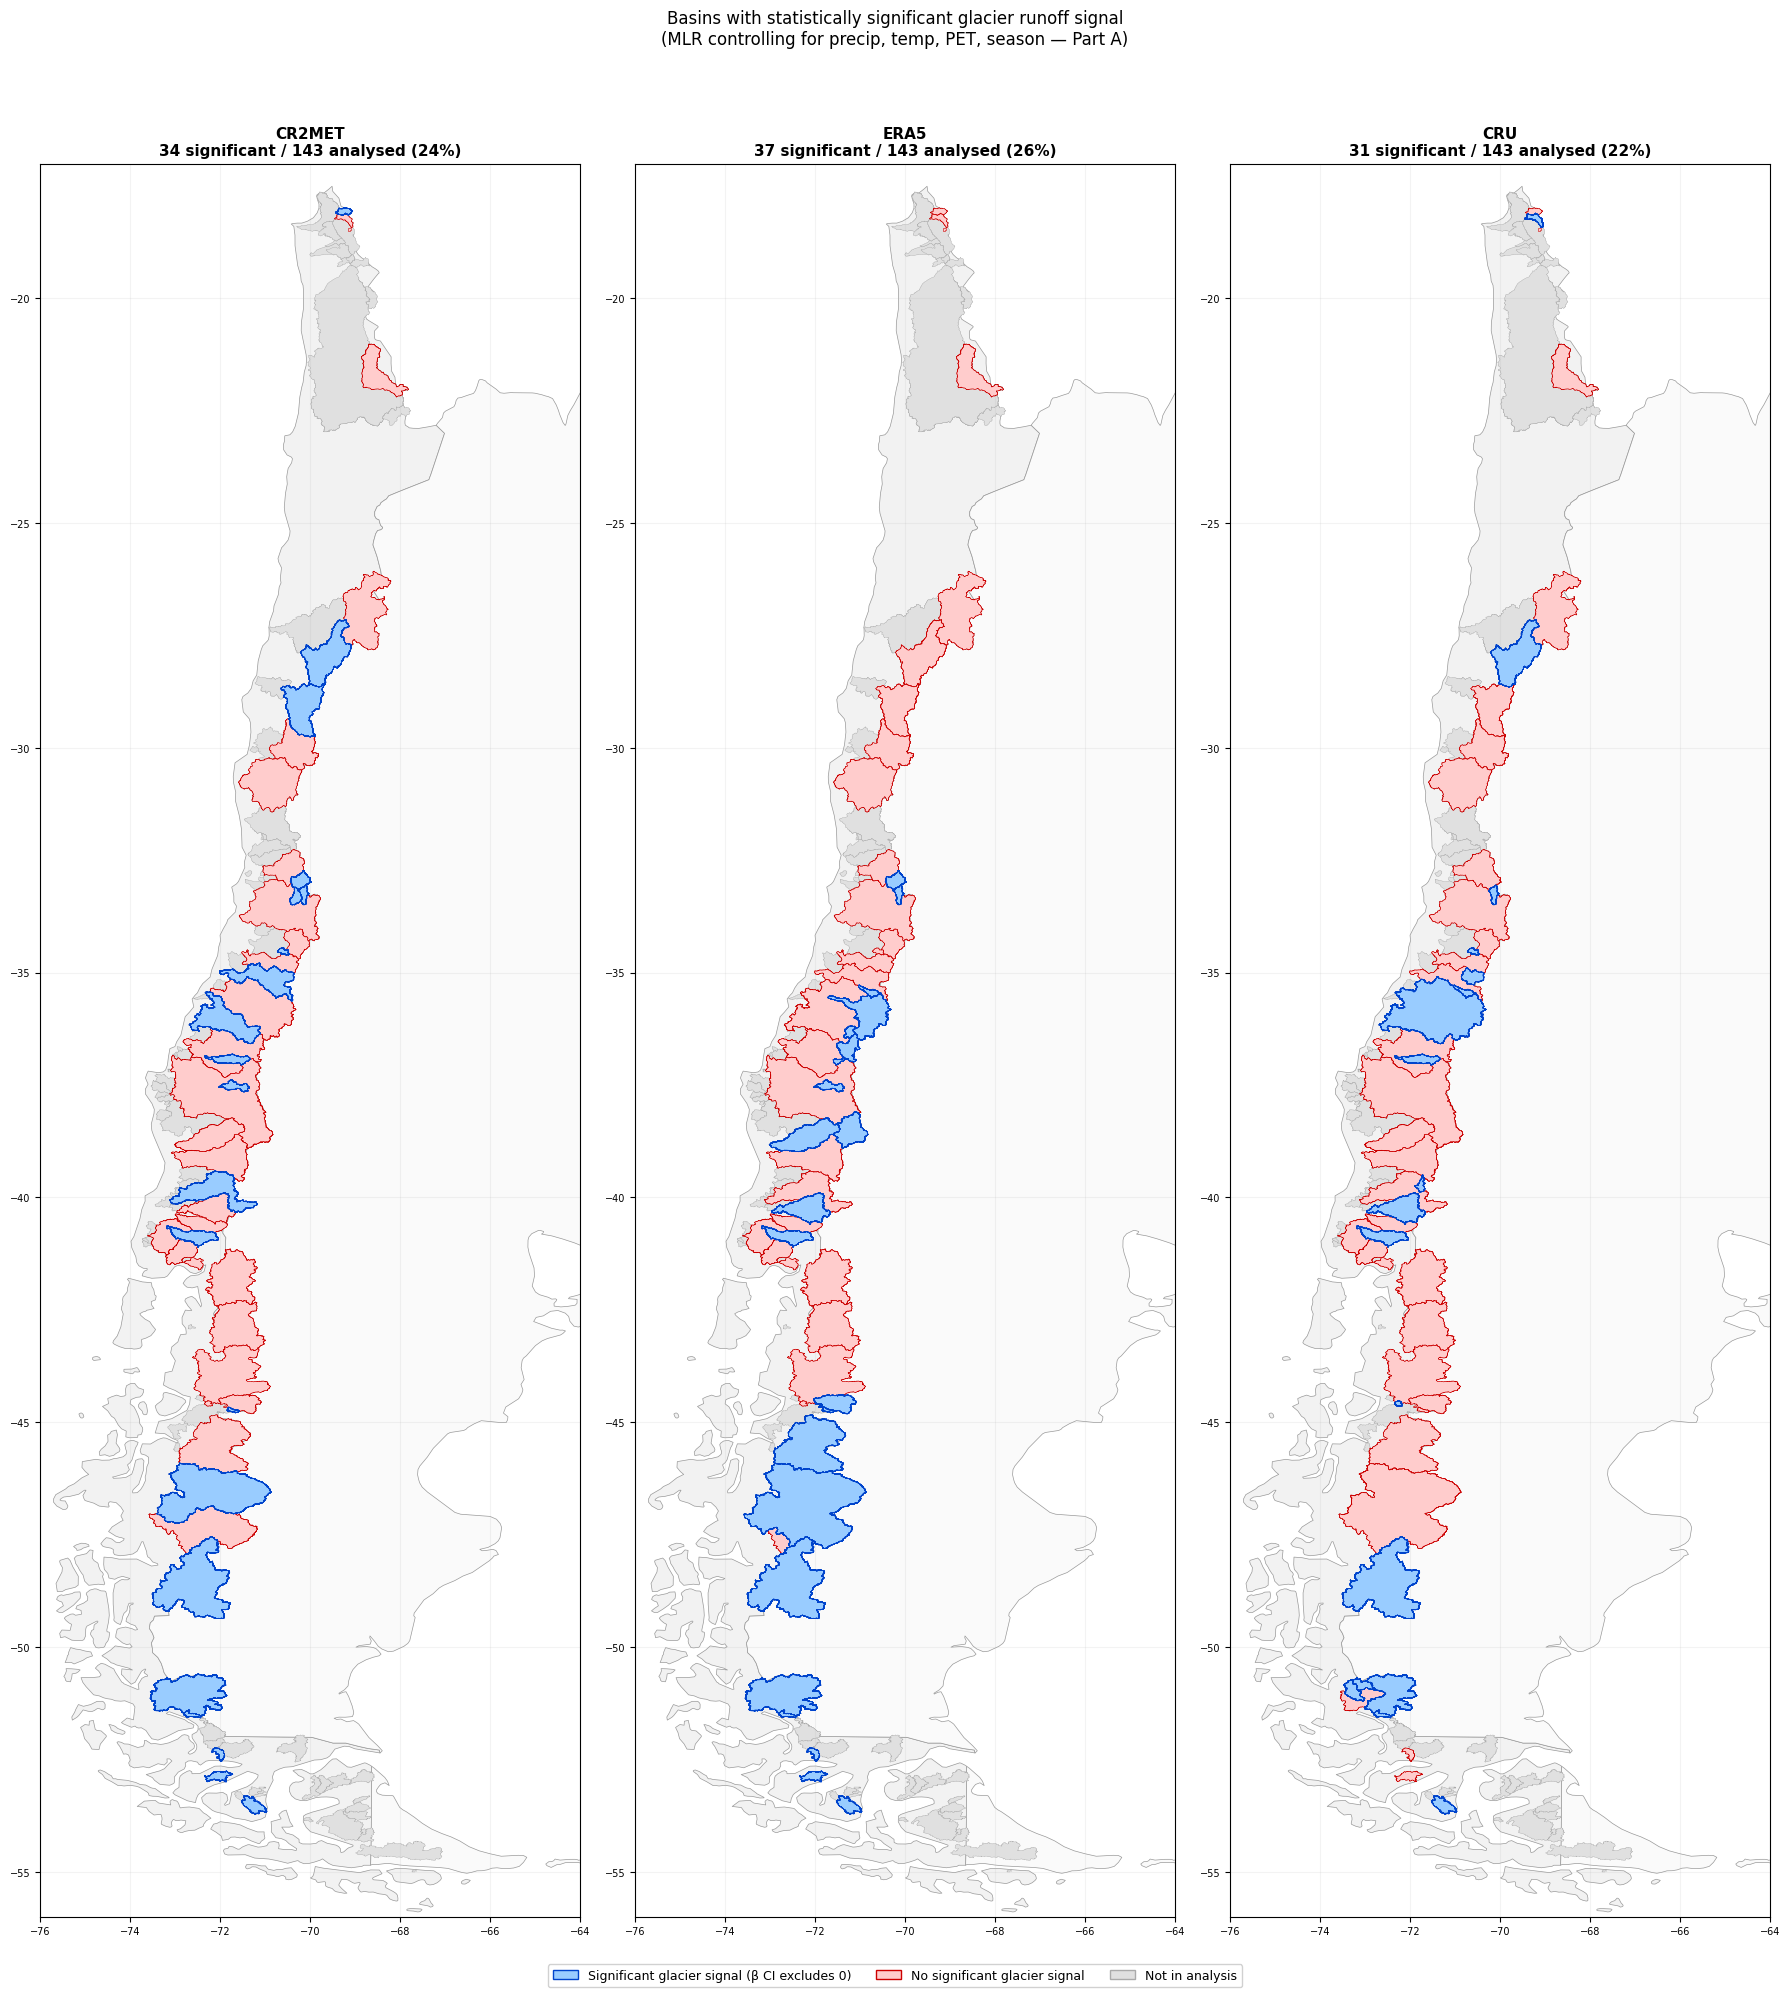

In [23]:
# ── Significance map: which basins show detectable glacier signal? ─────────

fig, axes = plt.subplots(1, 3, figsize=(18, 20))

# Load country borders if not already in memory
try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    chile       = world[world['NAME'] == 'Chile']
    arg         = world[world['NAME'] == 'Argentina']
    has_borders = True
except Exception:
    has_borders = False
    print('Country borders unavailable — plotting without')
    
for ax, ds_name in zip(axes, ['CR2MET', 'ERA5', 'CRU']):
    df   = PER_BASIN_A[ds_name].copy()
    df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
    sig_gauges = set(df[df['sig']]['gauge_id'])
    ns_gauges  = set(df[~df['sig']]['gauge_id'])

    if has_borders:
        chile.plot(ax=ax, facecolor='#f2f2f2',
                   edgecolor='#999999', linewidth=0.5, zorder=0)
        arg.plot(ax=ax, facecolor='#fafafa',
                 edgecolor='#999999', linewidth=0.5, zorder=0)

    # Non-significant basins — red
    bounds[bounds['gauge_id'].isin(ns_gauges)].plot(
        ax=ax, facecolor='#ffcccc', edgecolor='#cc0000',
        linewidth=0.4, zorder=2, label='Not significant')

    # Significant basins — blue
    bounds[bounds['gauge_id'].isin(sig_gauges)].plot(
        ax=ax, facecolor='#99ccff', edgecolor='#0044cc',
        linewidth=0.6, zorder=3, label='Significant')

    # Basins not in analysis — grey
    analysed = sig_gauges | ns_gauges
    bounds[~bounds['gauge_id'].isin(analysed)].plot(
        ax=ax, facecolor='#e0e0e0', edgecolor='#aaaaaa',
        linewidth=0.2, zorder=1)

    ax.set_xlim(-76, -64)
    ax.set_ylim(-56, -17)
    ax.set_aspect('equal')
    ax.set_title(f'{ds_name}\n{len(sig_gauges)} significant / '
                 f'{len(sig_gauges)+len(ns_gauges)} analysed '
                 f'({len(sig_gauges)/(len(sig_gauges)+len(ns_gauges))*100:.0f}%)',
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.15)
    ax.tick_params(labelsize=7)

    n_sig = len(sig_gauges)
    n_tot = len(sig_gauges) + len(ns_gauges)

fig.legend(
    handles=[
        Patch(facecolor='#99ccff', edgecolor='#0044cc',
              label='Significant glacier signal (β CI excludes 0)'),
        Patch(facecolor='#ffcccc', edgecolor='#cc0000',
              label='No significant glacier signal'),
        Patch(facecolor='#e0e0e0', edgecolor='#aaaaaa',
              label='Not in analysis'),
    ],
    loc='lower center', ncol=3, fontsize=9,
    bbox_to_anchor=(0.5, 0.01), framealpha=0.9)

fig.suptitle('Basins with statistically significant glacier runoff signal\n'
             '(MLR controlling for precip, temp, PET, season — Part A)',
             fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/significance_map_partA.png',
            dpi=150, bbox_inches='tight')
plt.show()

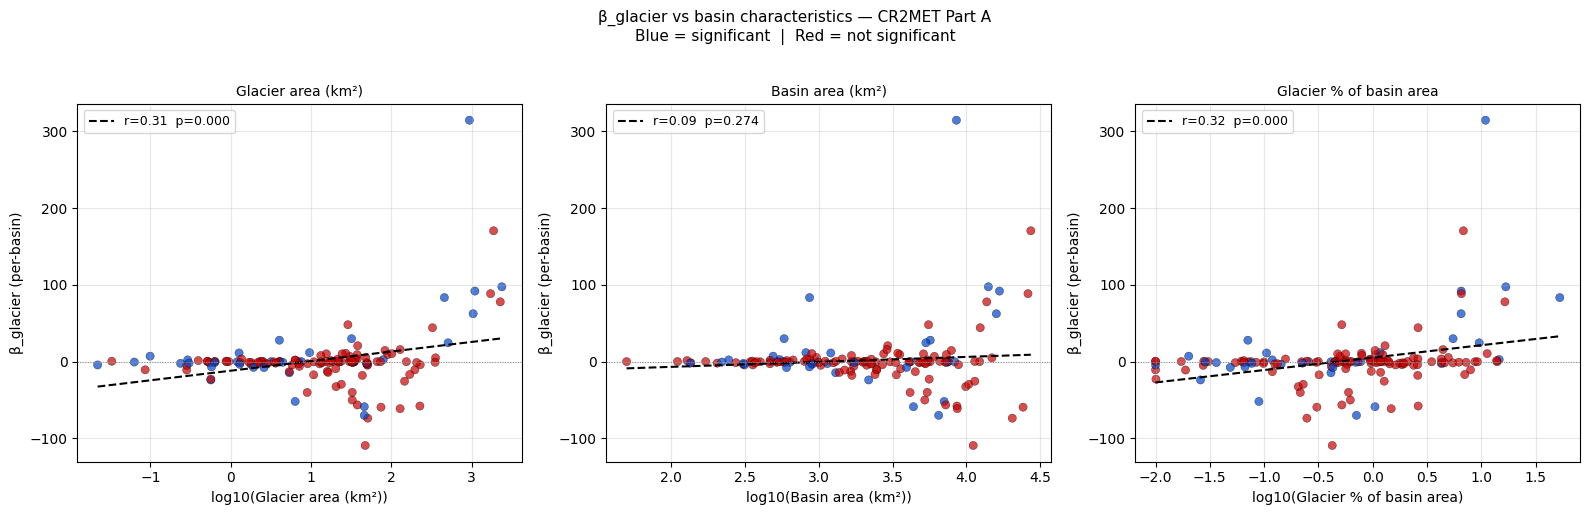

In [20]:
# ── Q3 extended: β_glacier vs area metrics ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ds_name = 'CR2MET'
df = PER_BASIN_A[ds_name].copy()
df['sig'] = (df[lo_col] > 0) | (df[hi_col] < 0)
df['glac_pct'] = df['glacier_area_km2'] / df.merge(
    pd.DataFrame([(gid, info['basin_area_km2'])
                  for gid, info in GAUGE_INFO_FRAC.items()],
                 columns=['gauge_id','basin_area_km2']),
    on='gauge_id')['basin_area_km2'] * 100

# Add basin area
basin_areas = pd.DataFrame([
    {'gauge_id': gid, 'basin_area_km2': info['basin_area_km2']}
    for gid, info in GAUGE_INFO_FRAC.items()])
df = df.merge(basin_areas, on='gauge_id', how='left')
df['glac_pct_basin'] = df['glacier_area_km2'] / df['basin_area_km2'] * 100

titles = ['Glacier area (km²)', 'Basin area (km²)',
          'Glacier % of basin area']
xcols  = ['glacier_area_km2', 'basin_area_km2', 'glac_pct_basin']
logs   = [True, True, True]

for ax, xcol, title, use_log in zip(axes, xcols, titles, logs):
    x = np.log10(df[xcol].clip(lower=0.01)) if use_log else df[xcol]
    ax.scatter(x, df[pred],
               c=['#0044cc' if s else '#cc0000' for s in df['sig']],
               s=35, alpha=0.7, edgecolors='k', lw=0.3)

    # Trend line
    valid = ~(np.isnan(x) | np.isnan(df[pred]))
    slope, intercept, r, p, _ = stats.linregress(x[valid], df.loc[valid, pred])
    xfit = np.linspace(x[valid].min(), x[valid].max(), 100)
    ax.plot(xfit, slope*xfit + intercept, 'k--', lw=1.5,
            label=f'r={r:.2f}  p={p:.3f}')
    ax.axhline(0, color='grey', lw=0.7, ls=':')
    ax.set_xlabel(f'log10({title})' if use_log else title, fontsize=10)
    ax.set_ylabel('β_glacier (per-basin)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'β_glacier vs basin characteristics — {ds_name} Part A\n'
             'Blue = significant  |  Red = not significant',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/beta_glacier_vs_basin_chars.png',
            dpi=150, bbox_inches='tight')
plt.show()